# Timeseries

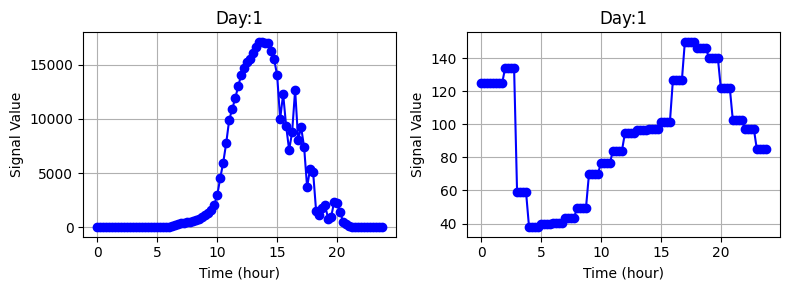

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from modules.solar import PVdata
from modules.economy import ElecPrice

pv_data_path = './data/timeseries-slimpark-2022.csv'
price_data_path='./data/day_ahead_prices_2022.csv'
PV_panel = PVdata(pv_data_path)
elec_price = ElecPrice(price_data_path)

expanded_pv = np.hstack([np.zeros(1,), PV_panel.day_data])
expanded_price = np.hstack([np.zeros(1,), elec_price.day_price_data])

# Create time axis for original and expanded data
time_axis_original = np.arange(0, 24, 1)
time_axis_expanded = np.arange(0, 24, 0.25)

# Plot the original and expanded data in subplots
plt.figure(figsize=(8, 3))
plt.subplot(1,2,1)
plt.plot(time_axis_expanded, expanded_pv[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)

plt.subplot(1,2,2)
# plt.plot(time_axis_original.astype(str), price_day[1:], marker='o', linestyle='-', color='g', label='Original Data (1 hour)')
plt.plot(time_axis_expanded, expanded_price[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)
plt.tight_layout()
plt.show()


# GMM

Total number of profiles: 2920


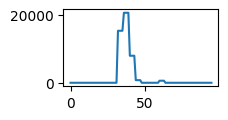

In [2]:
import pandas as pd
import numpy as np

# Load and preprocess data
df = pd.read_csv('data/power_and_active_sessions_cp_UT.csv')
df['date'] = pd.to_datetime(df['times']).dt.date

# Group by date
grouped = df.groupby('date')

# Initialize storage dictionaries
evse_cols = ['evse_1_wh', 'evse_2_wh', 'evse_3_wh', 'evse_4_wh']
evse_data = {col: [] for col in evse_cols}
power_profiles = []

# Iterate over each day's group
for date, group in grouped:
    if len(group) == 96:
        for col in evse_cols:
            evse_data[col].append(group[col].to_numpy())
        power_profiles.append(group['power'].to_numpy())

# Convert lists to numpy arrays
for col in evse_cols:
    evse_data[col] = np.array(evse_data[col])
    evse_data[col] = np.where(evse_data[col] < 10, 0, evse_data[col])

power_profiles = np.array(power_profiles)
power_profiles = np.where(power_profiles < 10, 0, power_profiles)

# Optional: unpack if you want the original variable names
evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh = (evse_data[col] for col in evse_cols)

all_profiles = np.concatenate((evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh), axis=0)
print(f"Total number of profiles: {len(all_profiles)}")

plt.figure(figsize=(2, 1))
plt.plot(all_profiles[12])

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from sklearn.cluster import KMeans
import numpy as np

class OnlineGMM:
    def __init__(self, num_components=2, buffer_size=200, lr=0.05):
        """Initialize the Online GMM with given parameters."""
        self.K = num_components
        self.buffer = deque(maxlen=buffer_size)
        
        # GMM parameters as PyTorch parameters
        self.means = nn.Parameter(torch.randn(self.K, 1))
        self.log_vars = nn.Parameter(torch.zeros(self.K, 1))
        self.logits = nn.Parameter(torch.zeros(self.K))
        
        # Optimizer
        self.optimizer = optim.Adam([self.means, self.log_vars, self.logits], lr=lr)

    def initialize_with_kmeans(self):
        """Initialize GMM means using KMeans on the buffer."""
        if len(self.buffer) < self.K:
            print("Not enough data to initialize with KMeans.")
            return
        
        data = np.array(self.buffer).reshape(-1, 1)
        kmeans = KMeans(n_clusters=self.K, n_init='auto').fit(data)
        centers = kmeans.cluster_centers_
        # Update the means with the KMeans centers
        with torch.no_grad():
            self.means.copy_(torch.tensor(centers, dtype=torch.float32))

    def gaussian_pdf(self, x, mu, log_var):
        """Compute the Gaussian probability density function."""
        var = torch.exp(log_var)
        return torch.exp(-0.5 * (x - mu)**2 / var) / torch.sqrt(2 * torch.pi * var)

    def update_model(self):
        """Perform one gradient update with the current buffer."""
        # Convert buffer to tensor
        x = torch.tensor(list(self.buffer), dtype=torch.float32).unsqueeze(1)
        
        # Gradient step
        self.optimizer.zero_grad()
        weights = torch.softmax(self.logits, dim=0)
        probs = torch.stack([w * self.gaussian_pdf(x, mu, lv) 
                             for w, mu, lv in zip(weights, self.means, self.log_vars)], dim=0)
        total_prob = torch.sum(probs, dim=0)
        nll = -torch.sum(torch.log(total_prob + 1e-8)) / len(x)
        nll.backward()
        self.optimizer.step()
        return nll.item()
    
    def sample(self, num_samples=1):
        """Sample from the GMM."""
        with torch.no_grad():
            weights = torch.softmax(self.logits, dim=0)
            components = torch.multinomial(weights, num_samples, replacement=True)
            samples = torch.normal(self.means[components], torch.exp(0.5 * self.log_vars[components]))
            return samples.numpy().flatten()

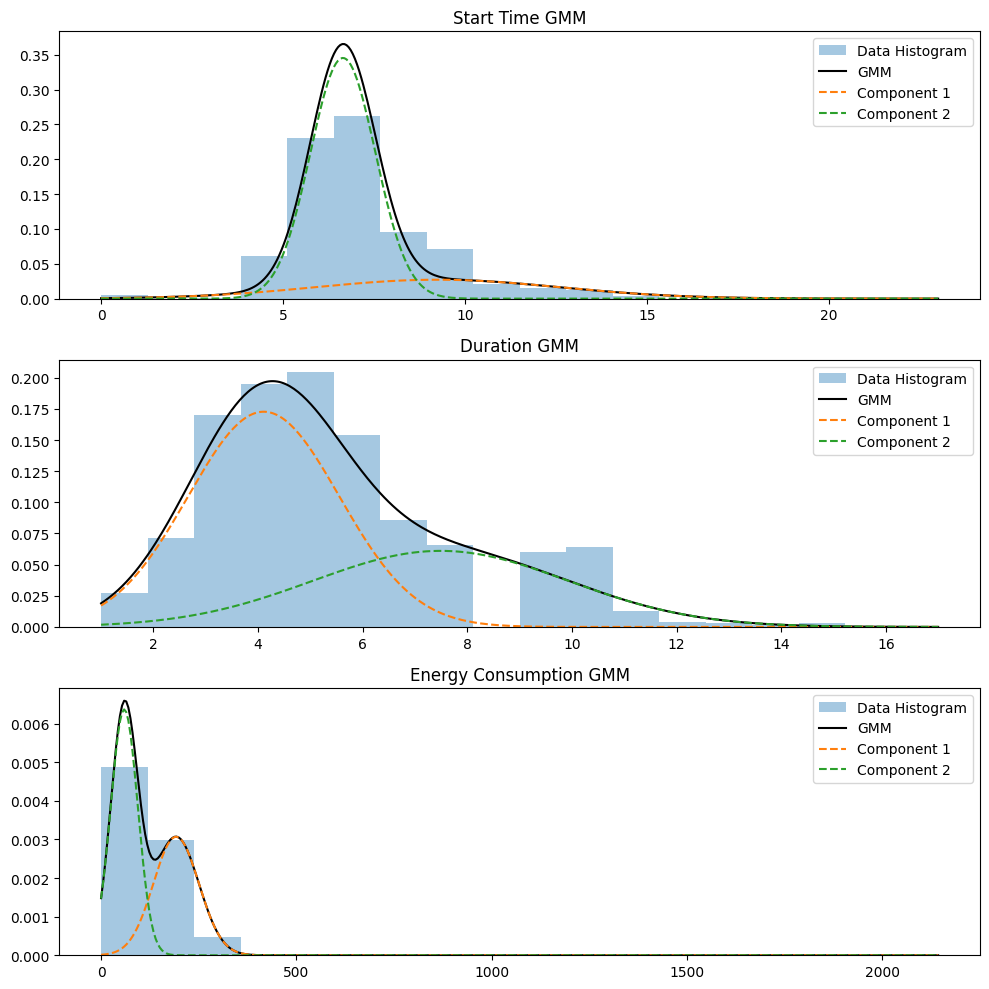

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Assume all_profiles is defined
start_times, durations, energy_consumptions = [], [], []

# Extract features from all_profiles
for prof_id in np.unique(np.where(all_profiles > 10)[0]):
    profile = all_profiles[prof_id]
    active_indices = np.where(profile > 0)[0]
    if len(active_indices) == 0:
        continue
    start = active_indices[0] / 4
    duration = len(active_indices) / 4
    energy = profile[active_indices].sum()/1000
    start_times.append(start)
    durations.append(duration)
    energy_consumptions.append(energy)

# Function to fit an OnlineGMM and return components for plotting
def fit_gmm(data):
    gmm = OnlineGMM(num_components=2, buffer_size=2000, lr=0.05)
    data = np.array(data)

    for point in data:
        gmm.buffer.append(point)
        if len(gmm.buffer) < 20:
            continue
        elif len(gmm.buffer) == 20:
            gmm.initialize_with_kmeans()
        else:
            gmm.update_model()
    
    return gmm, data

# Fit GMMs and keep data as well
gmm_results = {
    "Start Time": fit_gmm(start_times),
    "Duration": fit_gmm(durations),
    "Energy Consumption": fit_gmm(energy_consumptions)
}

# Plotting in 3 subplots with appropriate ranges
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

for ax, (title, (gmm, data)) in zip(axes, gmm_results.items()):
    x_vals = torch.linspace(min(data), max(data), 400).unsqueeze(1)
    weights = torch.softmax(gmm.logits, dim=0)
    components = [w * gmm.gaussian_pdf(x_vals, mu, lv) for w, mu, lv in zip(weights, gmm.means, gmm.log_vars)]
    mixture = torch.sum(torch.stack(components), dim=0)

    ax.hist(data, bins=18, density=True, alpha=0.4, label='Data Histogram')
    ax.plot(x_vals.detach(), mixture.detach(), color='black', label='GMM')
    for i, comp in enumerate(components):
        ax.plot(x_vals.detach(), comp.detach(), '--', label=f'Component {i+1}')
    ax.set_title(f'{title} GMM')
    ax.legend()

plt.tight_layout()
plt.show()


In [25]:
ev_data = torch.tensor(np.stack([start_times, durations, energy_consumptions], axis=1))

In [26]:
import torch.nn.functional as F

class MultivariateMDN(nn.Module):
    def __init__(self, n_components=3, output_dim=3):
        super().__init__()
        self.n_components = n_components
        self.output_dim = output_dim
        hidden_dim = 64

        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),  # you can use input=0 if unconditional
            nn.ReLU(),
        )

        self.pi = nn.Linear(hidden_dim, n_components)
        self.mu = nn.Linear(hidden_dim, n_components * output_dim)
        self.sigma = nn.Linear(hidden_dim, n_components * output_dim)

    def forward(self, x):
        h = self.net(x)
        pi = F.softmax(self.pi(h), dim=-1)  # (B, K)
        mu = self.mu(h).view(-1, self.n_components, self.output_dim)  # (B, K, D)
        sigma = torch.exp(self.sigma(h)).view(-1, self.n_components, self.output_dim) + 1e-6
        return pi, mu, sigma

    def log_prob(self, target, pi, mu, sigma):
        # target shape: (B, D)
        target = target.unsqueeze(1)  # (B, 1, D)
        prob = torch.exp(-0.5 * ((target - mu) / sigma)**2) / (sigma * (2 * torch.pi)**0.5)
        prob = prob.prod(dim=-1)  # Multiply across dimensions to get joint
        weighted_prob = pi * prob
        return torch.log(weighted_prob.sum(dim=-1) + 1e-8)

    def sample(self, batch_size=1):
        pi, mu, sigma = self.forward(torch.zeros((batch_size, 1)))
        dist = torch.distributions.Categorical(pi)
        idx = dist.sample()  # (B,)
        mu_chosen = mu[torch.arange(batch_size), idx]      # (B, D)
        sigma_chosen = sigma[torch.arange(batch_size), idx]
        eps = torch.randn_like(mu_chosen)
        return mu_chosen + sigma_chosen * eps


model = MultivariateMDN(n_components=3, output_dim=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

for epoch in range(1000):
    batch = ev_data  # shape: (B, 3)
    target = batch

    pi, mu, sigma = model(torch.rand((batch.shape[0], 1)))  # unconditional
    logp = model.log_prob(target, pi, mu, sigma)
    loss = -logp.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, loss = {loss.item():.4f}")


Epoch 0, loss = 18.3995
Epoch 100, loss = 10.6211
Epoch 200, loss = 10.4728
Epoch 300, loss = 10.1495
Epoch 400, loss = 10.0968
Epoch 500, loss = 10.0829
Epoch 600, loss = 10.0819
Epoch 700, loss = 10.0802
Epoch 800, loss = 10.0822
Epoch 900, loss = 10.0813


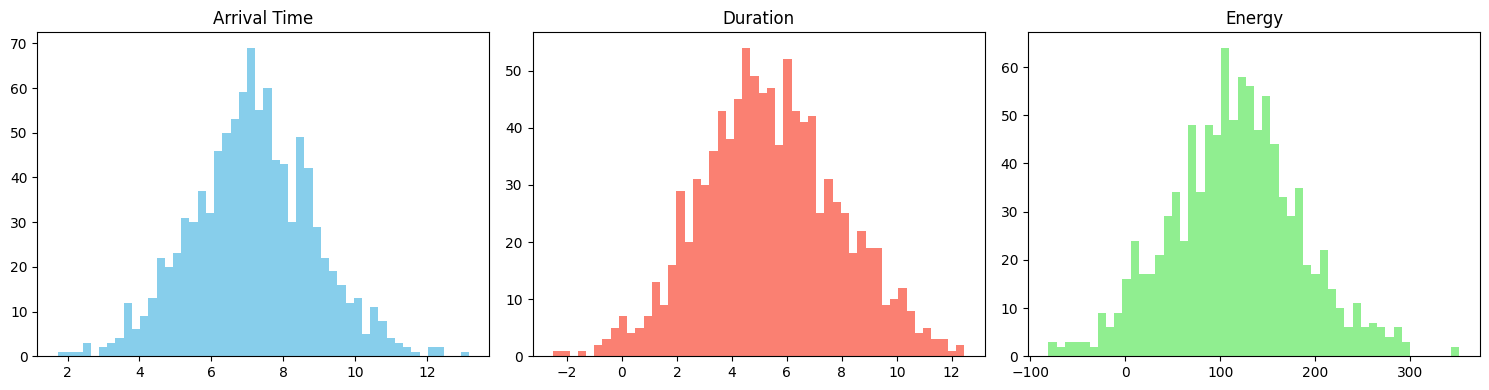

In [27]:
samples = model.sample(batch_size=1000)  # shape: (1000, 3)
arrival_samples = samples[:, 0]
duration_samples = samples[:, 1]
energy_samples = samples[:, 2]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(arrival_samples.cpu().detach().numpy(), bins=50, color='skyblue')
axes[0].set_title('Arrival Time')

axes[1].hist(duration_samples.cpu().detach().numpy(), bins=50, color='salmon')
axes[1].set_title('Duration')

axes[2].hist(energy_samples.cpu().detach().numpy(), bins=50, color='lightgreen')
axes[2].set_title('Energy')

plt.tight_layout()
plt.show()


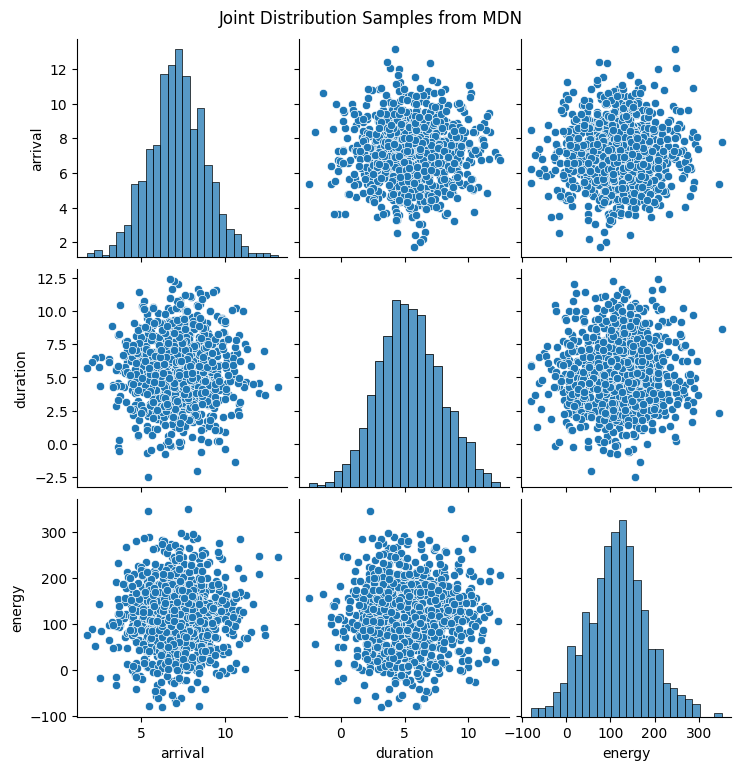

In [28]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame({
    "arrival": arrival_samples.cpu().detach().numpy(),
    "duration": duration_samples.cpu().detach().numpy(),
    "energy": energy_samples.cpu().detach().numpy()
})

sns.pairplot(df)
plt.suptitle("Joint Distribution Samples from MDN", y=1.02)
plt.show()


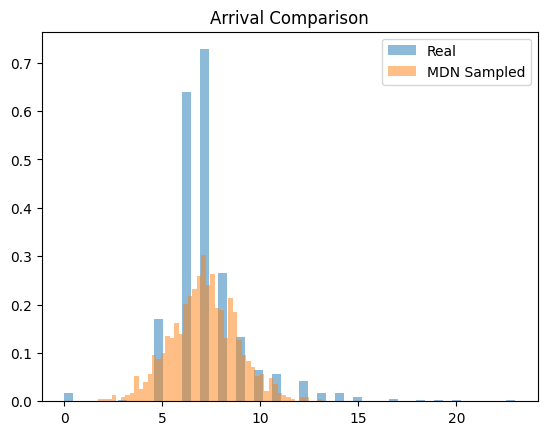

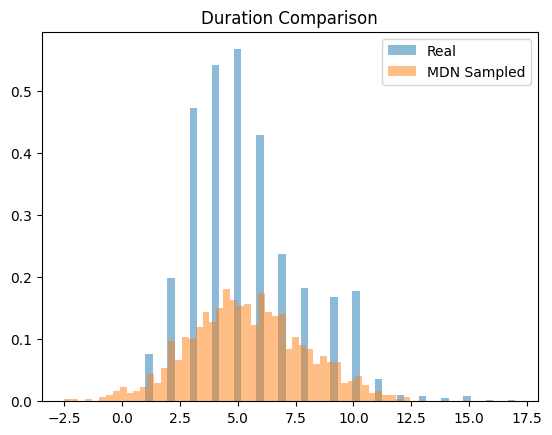

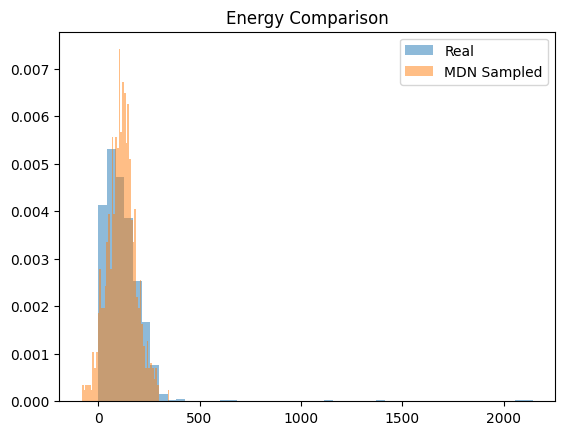

In [29]:
real_df = pd.DataFrame(ev_data, columns=["arrival", "duration", "energy"])
fake_df = pd.DataFrame(samples.cpu().detach().numpy(), columns=["arrival", "duration", "energy"])

# Overlay histograms
for col in ["arrival", "duration", "energy"]:
    plt.hist(real_df[col], bins=50, alpha=0.5, label='Real', density=True)
    plt.hist(fake_df[col], bins=50, alpha=0.5, label='MDN Sampled', density=True)
    plt.title(f"{col.capitalize()} Comparison")
    plt.legend()
    plt.show()


In [30]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

class MDN(nn.Module):
    def __init__(self, input_dim, output_dim, n_components=3, hidden_dim=64):
        super().__init__()
        self.n_components = n_components
        self.output_dim = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.pi = nn.Linear(hidden_dim, n_components)
        self.mu = nn.Linear(hidden_dim, n_components * output_dim)
        self.sigma = nn.Linear(hidden_dim, n_components * output_dim)

    def forward(self, x):
        h = self.net(x)
        pi = F.softmax(self.pi(h), dim=-1)                                     # (B, K)
        mu = self.mu(h).view(-1, self.n_components, self.output_dim)           # (B, K, D)
        sigma = torch.exp(self.sigma(h)).view(-1, self.n_components, self.output_dim) + 1e-6
        return pi, mu, sigma

    def log_prob(self, target, pi, mu, sigma):
        target = target.unsqueeze(1)                                           # (B, 1, D)
        prob = torch.exp(-0.5 * ((target - mu) / sigma)**2) / (sigma * (2 * np.pi)**0.5)
        prob = prob.prod(dim=-1)                                               # (B, K)
        weighted = pi * prob
        return torch.log(weighted.sum(dim=-1) + 1e-8)                           # (B,)

    def sample(self, pi, mu, sigma):
        batch_size = pi.size(0)
        cat = torch.distributions.Categorical(pi)
        indices = cat.sample()                                                 # (B,)
        mu_selected = mu[torch.arange(batch_size), indices]                   # (B, D)
        sigma_selected = sigma[torch.arange(batch_size), indices]
        eps = torch.randn_like(mu_selected)
        return mu_selected + sigma_selected * eps                              # (B, D)

mdn1 = MDN(input_dim=1, output_dim=1)       # p(arrival)
mdn2 = MDN(input_dim=1, output_dim=1)       # p(duration | arrival)
mdn3 = MDN(input_dim=2, output_dim=1)       # p(energy | arrival, duration)

optim = torch.optim.Adam(
    list(mdn1.parameters()) +
    list(mdn2.parameters()) +
    list(mdn3.parameters()), lr=1e-3
)

for epoch in range(10000):
    batch = ev_data  # shape: (B, 3)
    arrival = batch[:, 0:1].float()
    duration = batch[:, 1:2].float()
    energy = batch[:, 2:3].float()

    # MDN1: p(arrival)
    pi1, mu1, sigma1 = mdn1(torch.ones_like(arrival))  # cast to float32  # dummy input
    logp1 = mdn1.log_prob(arrival, pi1, mu1, sigma1)

    # MDN2: p(duration | arrival)
    pi2, mu2, sigma2 = mdn2(arrival)
    logp2 = mdn2.log_prob(duration, pi2, mu2, sigma2)

    # MDN3: p(energy | arrival, duration)
    x3 = torch.cat([arrival, duration], dim=1)
    pi3, mu3, sigma3 = mdn3(x3)
    logp3 = mdn3.log_prob(energy, pi3, mu3, sigma3)

    # Total negative log-likelihood loss
    loss = -(logp1 + logp2 + logp3).mean()

    optim.zero_grad()
    loss.backward()
    optim.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")

Epoch 0, Loss = 38.8530
Epoch 1000, Loss = 9.6584
Epoch 2000, Loss = 9.4534
Epoch 3000, Loss = 9.3187
Epoch 4000, Loss = 9.2822
Epoch 5000, Loss = 9.2843
Epoch 6000, Loss = 9.2760
Epoch 7000, Loss = 9.2703
Epoch 8000, Loss = 9.2658
Epoch 9000, Loss = 9.2615


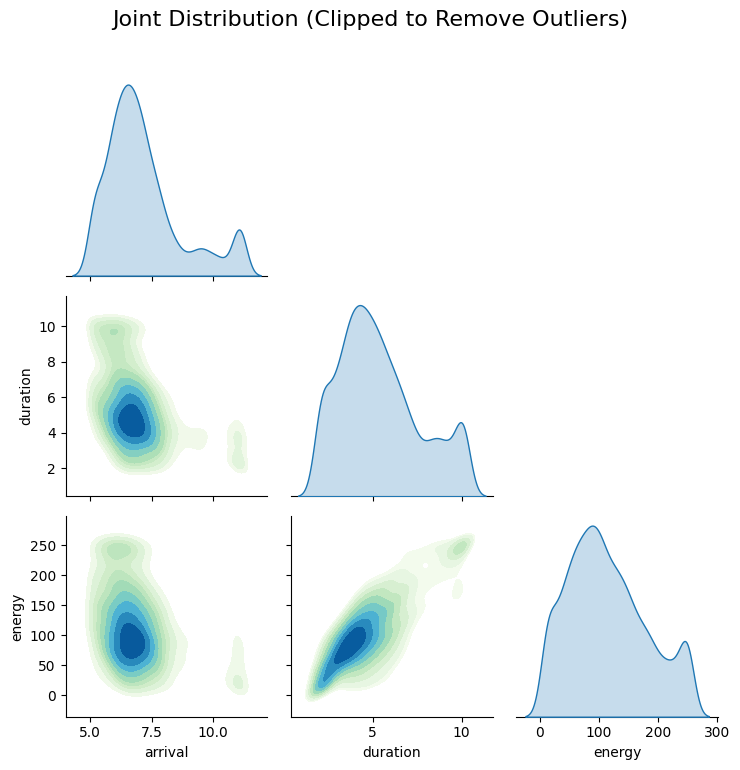

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def sample_autoregressive(mdn1, mdn2, mdn3, n_samples=1000):
    device = next(mdn1.parameters()).device

    # Step 1: sample x1 ~ p(x1)
    dummy_input = torch.ones(n_samples, 1).to(device)
    pi1, mu1, sigma1 = mdn1(dummy_input)
    x1 = mdn1.sample(pi1, mu1, sigma1)  # shape: (N, 1)

    # Step 2: sample x2 ~ p(x2 | x1)
    pi2, mu2, sigma2 = mdn2(x1)
    x2 = mdn2.sample(pi2, mu2, sigma2)  # shape: (N, 1)

    # Step 3: sample x3 ~ p(x3 | x1, x2)
    x12 = torch.cat([x1, x2], dim=1)
    pi3, mu3, sigma3 = mdn3(x12)
    x3 = mdn3.sample(pi3, mu3, sigma3)  # shape: (N, 1)

    # Final samples (N, 3)
    samples = torch.cat([x1, x2, x3], dim=1).detach().cpu().numpy()
    return samples


# Generate samples
samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=5000)

# Convert to DataFrame for seaborn
df_samples = pd.DataFrame(samples, columns=["arrival", "duration", "energy"])

def clip_outliers(df, lower=0.01, upper=0.99):
    return df.apply(lambda x: x.clip(lower=x.quantile(lower), upper=x.quantile(upper)))

df_clipped = clip_outliers(df_samples, lower=0.05, upper=0.95)

# Pairplot (joint distribution visualization)
# sns.pairplot(df_clipped, kind="kde", corner=True, plot_kws={"fill": True, "thresh": 0.05}
             
# sns.set(style="whitegrid")

g = sns.pairplot(
    df_clipped,
    kind="kde",  # use KDE for joint distributions
    diag_kind="kde",  # KDE for the diagonal too
    plot_kws={'cmap': 'GnBu', 'fill': True, 'thresh': 0.2},
    corner=True  # optional: only show lower triangle
)

plt.suptitle("Joint Distribution (Clipped to Remove Outliers)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [51]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

def truncate_colormap(cmap_name, minval=0.3, maxval=1.0, n=100):
    cmap = cm.get_cmap(cmap_name)
    new_cmap = colors.LinearSegmentedColormap.from_list(
        f'trunc({cmap_name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

dark_gnbu = truncate_colormap('GnBu', 0.35, 1.0)


/var/folders/qd/r2whwmq95rxdxbfpy2ntb4780000gn/T/ipykernel_2313/2850830411.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


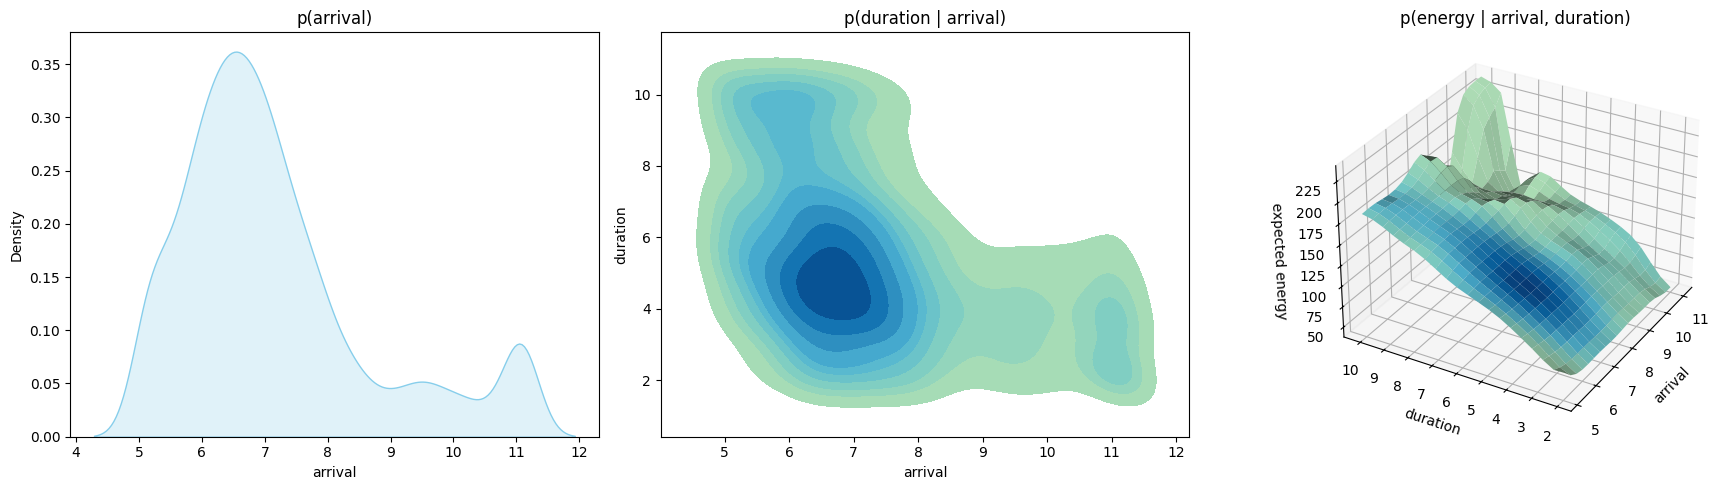

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(18, 5))

# 1D: p(arrival)
ax1 = fig.add_subplot(1, 3, 1)
sns.kdeplot(df_clipped['arrival'], fill=True, color='skyblue', ax=ax1)
ax1.set_title('p(arrival)')


# 2D: p(duration | arrival)
ax2 = fig.add_subplot(1, 3, 2)
sns.kdeplot(
    x=df_clipped['arrival'],
    y=df_clipped['duration'],
    fill=True,
    cmap=dark_gnbu,
    thresh=0.05,
    ax=ax2
)
ax2.set_title('p(duration | arrival)')

'''
# 3D: p(energy | arrival, duration)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(df_clipped['arrival'], df_clipped['duration'], df_clipped['energy'], c=df_clipped['energy'], cmap=dark_gnbu, s=5)
ax3.set_xlabel('arrival')
ax3.set_ylabel('duration')
ax3.set_zlabel('energy')
ax3.set_title('p(energy | arrival, duration)')
'''

# 3D: p(energy | arrival, duration) with density color
ax4 = fig.add_subplot(1, 3, 3, projection='3d')
# Prepare data for KDE
values = df_clipped[['arrival', 'duration', 'energy']].T.values
kde = gaussian_kde(values)

# Create meshgrid for arrival and duration
x = np.linspace(df_clipped['arrival'].min(), df_clipped['arrival'].max(), 20)
y = np.linspace(df_clipped['duration'].min(), df_clipped['duration'].max(), 20)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
density_values = np.zeros_like(X)

# Compute expected energy and density
energy_range = np.linspace(df_clipped['energy'].min(), df_clipped['energy'].max(), 100)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Evaluate KDE density over energy range
        density = np.array([kde([X[i, j], Y[i, j], e])[0] for e in energy_range])
        # Compute marginal density p(arrival, duration) by integrating over energy
        density_values[i, j] = np.sum(density) * (energy_range[1] - energy_range[0])
        # Compute expected energy: sum(density * energy) / sum(density)
        if np.sum(density) > 0:
            Z[i, j] = np.sum(density * energy_range) / np.sum(density)
        else:
            Z[i, j] = np.nanmean(df_clipped['energy'])  # Fallback to mean energy

# Normalize density_values for colormap (0 to 1)
density_norm = (density_values - density_values.min()) / (density_values.max() - density_values.min())

# Plot the surface with density color using custom colormap
surf = ax4.plot_surface(X, Y, Z, facecolors=dark_gnbu(density_norm), edgecolor='none', alpha=1)

ax4.set_xlabel('arrival')
ax4.set_ylabel('duration')
ax4.set_zlabel('expected energy')
ax4.set_title('p(energy | arrival, duration)')
# fig.colorbar(surf, shrink=0.5, aspect=10, label='Density')

# Set rotation: elevation (30 degrees) and azimuth (-150 degrees)
ax4.view_init(elev=30, azim=-150)

plt.tight_layout()
plt.show()

# Generator

In [ ]:
samples = model.sample(batch_size=10)  # shape: (1000, 3)
arrival_samples = samples[:, 0]
duration_samples = samples[:, 1]
energy_samples = samples[:, 2]

print("Sampled Arrival Times:", arrival_samples.cpu().detach().numpy())
print("Sampled Durations:", duration_samples.cpu().detach().numpy())
print("Sampled Energy Consumptions:", energy_samples.cpu().detach().numpy())

Sampled Arrival Times: [7.457344  6.320856  7.871543  9.973339  6.936954  7.4488583 6.4061317
 7.524229  5.053297  5.812264 ]
Sampled Durations: [6.651203  6.378648  5.587741  6.2714977 2.5192127 3.545227  8.547112
 4.331259  8.569864  5.3511596]
Sampled Energy Consumptions: [ 60.317883  62.025455 125.422615  59.76402  125.80592  123.12172
 192.68034   75.5261   142.02135  160.70924 ]


In [ ]:
# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.8
capacity_low_imit = 0.2

charge_discharge_limit = 14  # Example charge/discharge limit
p_charger_limit = 11

In [ ]:
from modules.parking import EVParkingLot
from modules.parking import EvDemandGenerator

np.random.seed(0)
parking_lot = EVParkingLot()
ev_demand_generator = EvDemandGenerator()

parking_lot.reset_day(day_type='weekday', parking_type='workplace')
ev_demand_initial_sample = ev_demand_generator.generate_demand(4).ravel()#*1.5 increase demand values
charger_availability_data = np.hstack([parking_lot.chargers[i].availability.reshape(-1,1) for i in range(parking_lot.num_chargers)])
charger_availability_data = np.vstack([np.zeros((1,4)), charger_availability_data])

In [ ]:
ev_demand_initial_sample.shape, charger_availability_data.shape

((4,), (97, 4))

In [ ]:
ev_demand_initial_sample

array([40.338, 10.378, 14.414, 12.203])

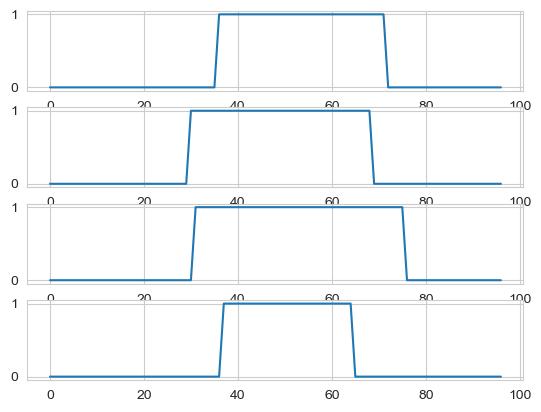

In [ ]:

for i in range(4):
    plt.subplot(4,1,i+1)
    plt.plot(charger_availability_data[:,i])

# with p_grid

                                     CVXPY                                     
                                     v1.5.2                                    
(CVXPY) Feb 06 04:45:44 PM: Your problem has 1067 variables, 1365 constraints, and 0 parameters.
(CVXPY) Feb 06 04:45:44 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 06 04:45:44 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 06 04:45:44 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 06 04:45:44 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 06 04:45:44 PM: Compiling problem (target solver=SCIP).

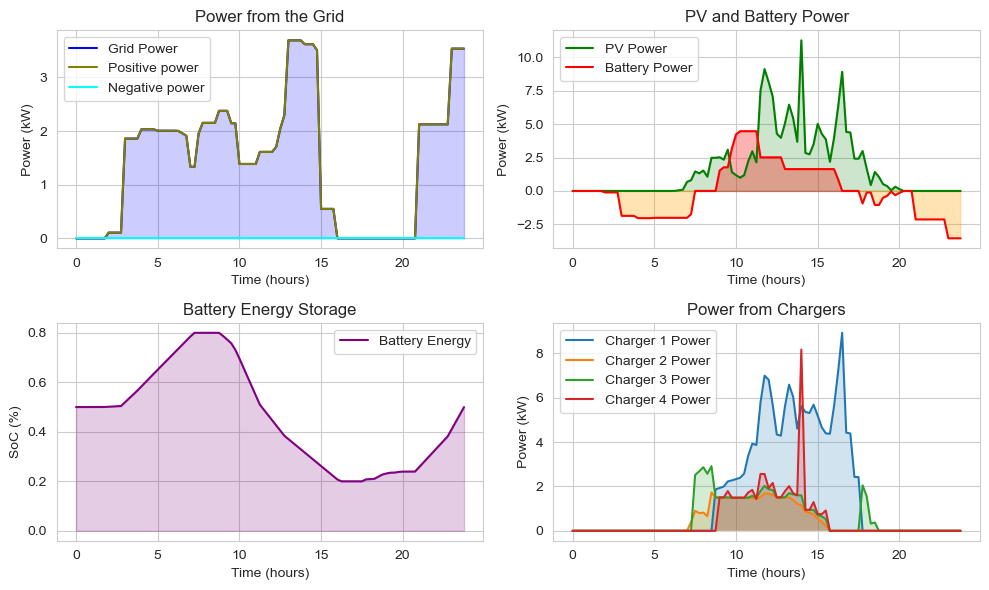

In [ ]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

p_pv = data_day[:num_time_steps+1, 4]/ 1000  # PV power generation over time (size: num_time_steps)
charger_availability = charger_availability_data  # Charger availability (size: num_chargers x num_time_steps)
ev_demand = ev_demand_initial_sample.ravel()  # Demand for each EV (size: num_chargers)
price = expanded_prices[:num_time_steps+1]

time_resolution = 0.25  # 15 minutes

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_limit = 0.8
capacity_low_limit = 0.2

charge_discharge_limit = 14  # Example charge/discharge limit
p_charger_limit = 11

# Decision Variables
p_chargers = cp.Variable((num_time_steps+1, num_chargers), nonneg=True)
p_grid = cp.Variable(num_time_steps+1)
p_grid_positive = cp.Variable(num_time_steps+1, nonneg=True)
p_grid_negative = cp.Variable(num_time_steps+1, nonneg=True)
p_storage = cp.Variable(num_time_steps+1)
storage_energy = cp.Variable(num_time_steps+1, nonneg=True)
slack = cp.Variable(num_time_steps+1)  # Slack variable for power balance constraints

# Binary variables for big-M method
binary_pos = cp.Variable(num_time_steps+1, boolean=True)

# Big-M constant
M = 1e5

# Constraints
constraints = []

# Charger availability constraints
constraints.append(p_chargers <= charger_availability * p_charger_limit)

# Power balance constraints
constraints.append(p_pv + p_grid + p_storage + slack == cp.sum(p_chargers, axis=1))

constraints.append(storage_energy <= storage_capacity * capacity_high_limit)
constraints.append(storage_energy >= storage_capacity * capacity_low_limit)
constraints.append(p_storage <= charge_discharge_limit)
constraints.append(p_storage >= -charge_discharge_limit)
constraints.append(storage_energy[0] == storage_capacity / 2)  # Initial storage level
constraints.append(storage_energy[-1] == storage_capacity / 2)

constraints.append(storage_energy[1:] == storage_energy[:-1] - p_storage[1:] * time_resolution)

# Initial conditions
# constraints.append(self.p_grid[0] == self.p_grid_initial)
constraints.append(p_grid_positive[0] == 0)
constraints.append(p_grid_negative[0] == 0)

# EV demand constraints
constraints.append(cp.sum(p_chargers * time_resolution, axis=0) >= ev_demand)

# Auxiliary variables constraints
constraints.append(p_grid == p_grid_positive - p_grid_negative)

# Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
constraints.append(binary_pos <= 1)
constraints.append(p_grid_positive <= binary_pos * M)
constraints.append(p_grid_negative <= (1-binary_pos) * M)

# Smoothing constraint to avoid abrupt changes
smoothing_penalty = cp.tv(p_grid_positive) + cp.tv(p_grid_negative) + cp.tv(p_storage) + 2*cp.tv(p_chargers) 

# Objective: Minimize total grid power usage, slack, and smoothing
objective = cp.Minimize(
    cp.sum(p_grid ** 2) +
    cp.sum(cp.multiply(price, p_grid_positive)) * 1000 -
    cp.sum(cp.multiply(price/2, p_grid_negative)) * 1000 +
    cp.sum(slack ** 2) * 1e3 +
    smoothing_penalty
)

# Problem definition and solving
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCIP, verbose=True)

# Output the results
print("Problem status:", problem.status)
if problem.status not in ["infeasible", "unbounded"]:
    print("Optimal objective value:", objective.value)
else:
    print("The problem is infeasible or unbounded.")

plt.figure(figsize=(10, 6))
time_steps = np.arange(len(p_grid.value[1:])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 2, 1)
plt.plot(time_steps, p_grid.value[1:], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, p_grid.value[1:], color='blue', alpha=0.2)
plt.plot(time_steps, p_grid_positive.value[1:], label='Positive power', color='olive')
plt.plot(time_steps, -p_grid_negative.value[1:], label='Negative power', color='cyan')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 2, 2)
plt.plot(time_steps, p_pv[1:], label='PV Power', color='green')
plt.fill_between(time_steps, 0, p_pv[1:], color='green', alpha=0.2)
plt.plot(time_steps, p_storage.value[1:], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 2, 3)
plt.plot(time_steps, np.array(storage_energy.value[1:]) / storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(storage_energy.value[1:]) / storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot charger power
plt.subplot(2, 2, 4)
for i in range(4):
    plt.plot(time_steps, p_chargers.value[1:, i], label=f'Charger {i + 1} Power')
    plt.fill_between(time_steps, 0, p_chargers.value[1:, i], alpha=0.2)

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()


### execution

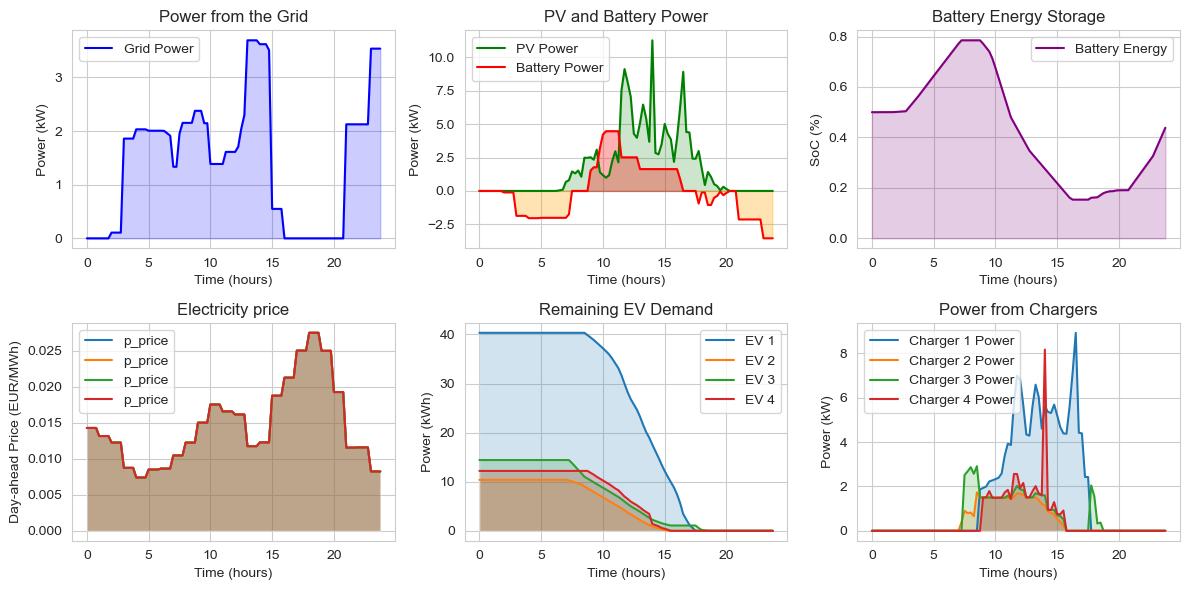

In [ ]:
# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

ev_demand_initial = ev_demand_initial_sample.reshape(1,4) # Example EV demand
storage_energy_initial = np.array([storage_capacity]) / 2

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.8
capacity_low_imit = 0.2

current_time = 0
time_shift = 1

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'ideal_storage_energy': storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'remaining_demand': ev_demand_initial,
}

num_chargers=4
time_resolution=0.25
storage_capacity=30     
capacity_high_limit=0.8
capacity_low_limit=0.2
p_storage_limit=14
p_charger_limit=11

for t in range(1, num_time_steps+1, time_shift):
    p_pv = data_day[t, 4]/ 1000  # PV power generation over time
    charger_availability = charger_availability_data[t, :num_chargers]  # Charger availability
    p_price = expanded_prices[t]

    p_chargers_exec = p_chargers.value[t]
    p_grid_exec  = p_grid.value[t]
    p_storage_exec  = p_storage.value[t]
    # print(p_pv.shape, charger_availability.shape, p_price.shape, p_pv)

    # apply dynamics of storage and demands
    storage_energy_sample = results['storage_energy'][-1] - (1/0.95)*np.maximum(0, p_storage_exec)*time_resolution -\
                                                            (0.95)*np.minimum(0, p_storage_exec)*time_resolution
    ideal_storage_energy_sample = results['ideal_storage_energy'][-1] - np.maximum(0, p_storage_exec)*time_resolution -\
                                                            np.minimum(0, p_storage_exec)*time_resolution
    
    ev_demand_sample = results['remaining_demand'][-1] - p_chargers_exec*time_resolution
    
    # Store results
    results['p_grid'] = np.hstack([results['p_grid'], p_grid_exec])

    results['p_storage'] = np.hstack([results['p_storage'], p_storage_exec])
    results['p_chargers'] = np.vstack([results['p_chargers'], p_chargers_exec])
    results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_sample])
    results['ideal_storage_energy'] = np.hstack([results['ideal_storage_energy'], ideal_storage_energy_sample])
    results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_sample])
    
    # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]

plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, data_day[1:1+len(time_steps),4]/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, data_day[1:1+len(time_steps),4]/1000, color='green', alpha=0.2)
plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_prices[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_prices[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
ideal = np.array(results['ideal_storage_energy'])/storage_capacity
one_time = np.array(results['storage_energy'])/storage_capacity

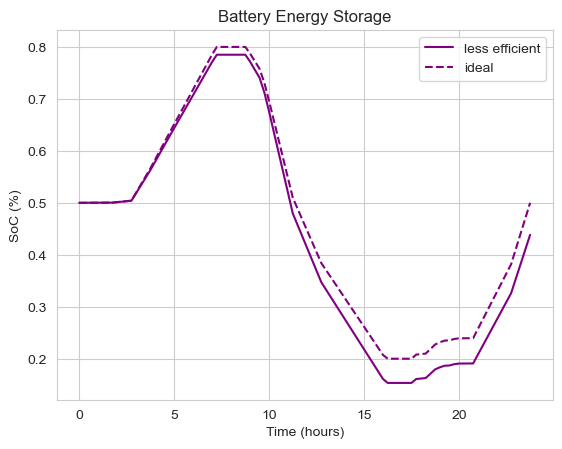

In [ ]:
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='less efficient', color='purple')
plt.plot(time_steps, np.array(results['ideal_storage_energy'])/storage_capacity, '--', label='ideal', color='purple')

# plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

In [ ]:
storage_capacity

30

In [ ]:
np.maximum(0, -p_grid.value[1:])*expanded_prices[1:1+len(time_steps)]

array([-0., -0., -0., -0., -0., -0., -0., -0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.])

In [ ]:
np.sum(np.maximum(0, p_grid.value[1:])*expanded_prices[1:1+len(time_steps)])

1.6094188730680858

In [ ]:
np.sum(np.maximum(0, -p_grid.value[1:])*expanded_prices[1:1+len(time_steps)]/2)

0.0

In [ ]:
dev_power = storage_capacity/2-np.array(results['storage_energy'])[-1]
np.sum(np.maximum(0, p_grid.value[1:])*expanded_prices[1:1+len(time_steps)] -\
        np.maximum(0, -p_grid.value[1:])*expanded_prices[1:1+len(time_steps)]/2) +\
        np.maximum(0, dev_power)*expanded_prices.max()*4 -\
        np.maximum(0, -dev_power)*expanded_prices.max()/2*4

1.81244466254177

In [ ]:
dev_power

1.8473684210526304

In [ ]:
dev_power

1.8473684210526304

In [ ]:
expanded_prices[1:1+len(time_steps)]

array([0.01427  , 0.01427  , 0.01427  , 0.01427  , 0.0131475, 0.0131475,
       0.0131475, 0.0131475, 0.0122425, 0.0122425, 0.0122425, 0.0122425,
       0.008735 , 0.008735 , 0.008735 , 0.008735 , 0.00739  , 0.00739  ,
       0.00739  , 0.00739  , 0.0084925, 0.0084925, 0.0084925, 0.0084925,
       0.00863  , 0.00863  , 0.00863  , 0.00863  , 0.01045  , 0.01045  ,
       0.01045  , 0.01045  , 0.0122375, 0.0122375, 0.0122375, 0.0122375,
       0.0150025, 0.0150025, 0.0150025, 0.0150025, 0.0175225, 0.0175225,
       0.0175225, 0.0175225, 0.016565 , 0.016565 , 0.016565 , 0.016565 ,
       0.016135 , 0.016135 , 0.016135 , 0.016135 , 0.01174  , 0.01174  ,
       0.01174  , 0.01174  , 0.012265 , 0.012265 , 0.012265 , 0.012265 ,
       0.0187475, 0.0187475, 0.0187475, 0.0187475, 0.02125  , 0.02125  ,
       0.02125  , 0.02125  , 0.025    , 0.025    , 0.025    , 0.025    ,
       0.027475 , 0.027475 , 0.027475 , 0.027475 , 0.024975 , 0.024975 ,
       0.024975 , 0.024975 , 0.01925  , 0.01925  , 

In [ ]:
np.sum(np.abs(p_grid.value[1:])*co2_repeated)/4

NameError: name 'co2_repeated' is not defined

In [ ]:
p_grid_one_time = results['p_grid']

# no p_grid

                                     CVXPY                                     
                                     v1.5.2                                    
(CVXPY) Feb 06 04:47:53 PM: Your problem has 960 variables, 1253 constraints, and 0 parameters.
(CVXPY) Feb 06 04:47:53 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 06 04:47:53 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 06 04:47:53 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 06 04:47:53 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 06 04:47:53 PM: Compiling problem (target solver=SCIP).


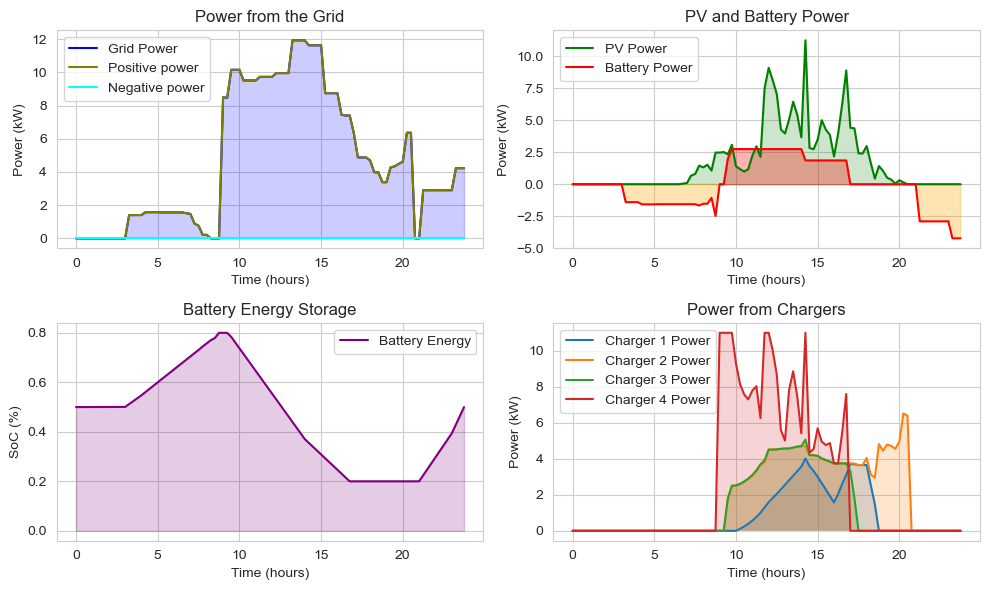

In [ ]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

p_pv = data_day[:num_time_steps, 4]/ 1000  # PV power generation over time (size: num_time_steps)
charger_availability = data_day[:num_time_steps, :4]  # Charger availability (size: num_chargers x num_time_steps)
ev_demand = np.array([20, 45, 30, 60])  # Demand for each EV (size: num_chargers)
price = expanded_prices[:num_time_steps]

time_resolution = 0.25  # 15 minutes

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_limit = 0.8
capacity_low_limit = 0.2

charge_discharge_limit = 14  # Example charge/discharge limit
p_charger_limit = 11

# Decision Variables
p_chargers = cp.Variable((num_time_steps, num_chargers), nonneg=True)
p_grid_positive = cp.Variable(num_time_steps, nonneg=True)
p_grid_negative = cp.Variable(num_time_steps, nonneg=True)
p_storage = cp.Variable(num_time_steps)
storage_energy = cp.Variable(num_time_steps, nonneg=True)
slack = cp.Variable(num_time_steps)  # Slack variable for power balance constraints

# Binary variables for big-M method
binary_pos = cp.Variable(num_time_steps, boolean=True)

# Big-M constant
M = 1e5

# Constraints
constraints = []

# Charger availability constraints
constraints.append(p_chargers <= charger_availability * p_charger_limit)

# Power balance constraints
constraints.append(p_pv + p_grid_positive - p_grid_negative + p_storage + slack == cp.sum(p_chargers, axis=1))
# constraints.append(p_grid_negative == 0)

constraints.append(storage_energy <= storage_capacity * capacity_high_limit)
constraints.append(storage_energy >= storage_capacity * capacity_low_limit)
constraints.append(p_storage <= charge_discharge_limit)
constraints.append(p_storage >= -charge_discharge_limit)
constraints.append(storage_energy[0] == storage_capacity / 2)  # Initial storage level
constraints.append(storage_energy[-1] == storage_capacity / 2)

constraints.append(storage_energy[1:] == storage_energy[:-1] - p_storage[1:] * time_resolution)

# EV demand constraints
constraints.append(cp.sum(p_chargers * time_resolution, axis=0) >= ev_demand)

# Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
constraints.append(binary_pos <= 1)
constraints.append(p_grid_positive <= binary_pos * M)
constraints.append(p_grid_negative <= (1-binary_pos) * M)

# Smoothing constraint to avoid abrupt changes
smoothing_penalty = cp.tv(p_grid_positive) + cp.tv(p_grid_negative) + cp.tv(p_storage) + 2*cp.tv(p_chargers) 

# Objective: Minimize total grid power usage, slack, and smoothing
objective = cp.Minimize(
    cp.sum(p_grid_positive ** 2) +
    cp.sum(p_grid_negative ** 2) +
    cp.sum(cp.multiply(price, p_grid_positive)) * 1000 -
    cp.sum(cp.multiply(price/2, p_grid_negative)) * 1000 +
    cp.sum(slack ** 2) * 1e3 +
    smoothing_penalty
)

# Problem definition and solving
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCIP, verbose=True)

# Output the results
print("Problem status:", problem.status)
if problem.status not in ["infeasible", "unbounded"]:
    print("Optimal objective value:", objective.value)
else:
    print("The problem is infeasible or unbounded.")

plt.figure(figsize=(10, 6))
time_steps = np.arange(len(p_grid_positive.value)) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 2, 1)
plt.plot(time_steps, p_grid_positive.value-p_grid_negative.value, label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, p_grid_positive.value-p_grid_negative.value, color='blue', alpha=0.2)
plt.plot(time_steps, p_grid_positive.value, label='Positive power', color='olive')
plt.plot(time_steps, -p_grid_negative.value, label='Negative power', color='cyan')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 2, 2)
plt.plot(time_steps, p_pv, label='PV Power', color='green')
plt.fill_between(time_steps, 0, p_pv, color='green', alpha=0.2)
plt.plot(time_steps, p_storage.value, label='Battery Power', color='red')
plt.fill_between(time_steps, 0, p_storage.value, where=np.array(p_storage.value) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, p_storage.value, where=np.array(p_storage.value) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 2, 3)
plt.plot(time_steps, np.array(storage_energy.value) / storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(storage_energy.value) / storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot charger power
plt.subplot(2, 2, 4)
for i in range(4):
    plt.plot(time_steps, p_chargers.value[:, i], label=f'Charger {i + 1} Power')
    plt.fill_between(time_steps, 0, p_chargers.value[:, i], alpha=0.2)

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()


# sliding window

(97,) (4,) (97, 4) 15.0
(89,) (4,) (89, 4) 15.01155138015747
(81,) (4,) (81, 4) 16.89229686643894
(73,) (4,) (73, 4) 20.794451477831906
(65,) (4,) (65, 4) 23.839722573891596
(57,) (4,) (57, 4) 21.79393235540606
(49,) (4,) (49, 4) 13.386132924449699
(41,) (4,) (41, 4) 9.23911736719228
(33,) (4,) (33, 4) 6.369628361008597
(25,) (4,) (25, 4) 6.1181892941139235
(17,) (4,) (17, 4) 6.946469232401252
(9,) (4,) (9, 4) 9.078153384782894


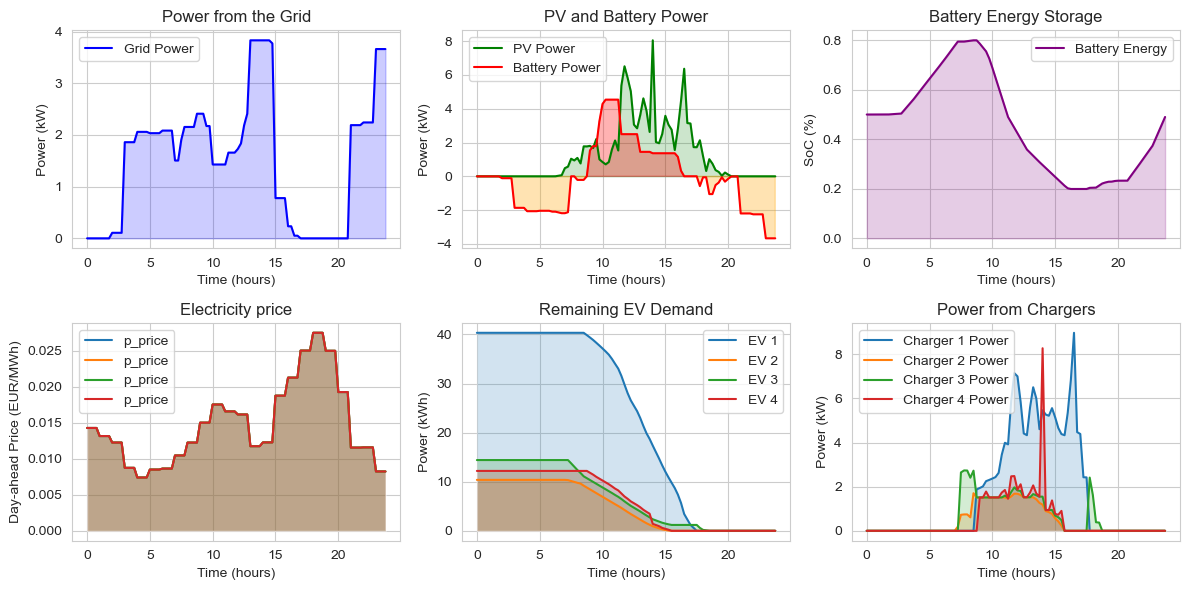

In [ ]:
import cvxpy as cp
import numpy as np

class MPC:
    def __init__(self, num_chargers=4, time_resolution=0.25, storage_capacity=30,
                 capacity_high_limit=0.8, capacity_low_limit=0.2, p_storage_limit=14, p_charger_limit=11):
        self.num_chargers = num_chargers
        self.time_resolution = time_resolution
        self.storage_capacity = storage_capacity
        self.capacity_high_limit = capacity_high_limit
        self.capacity_low_limit = capacity_low_limit
        self.p_storage_limit = p_storage_limit
        self.p_charger_limit = p_charger_limit

        # 2 hours * resolution
        self.time_shift = 2 * int(1 / self.time_resolution)  
        # Big-M constant
        self.M = 1e5

    def step(self, p_pv, results, charger_availability, p_price):
        self.num_time_steps = len(p_pv)  # 24 hours * resolution

        # Initialize parameters
        self.p_grid_initial = cp.Parameter(1, value=results['p_grid'][-1:])
        self.p_grid_positive_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_positive'][-1:], 0, np.inf))
        self.p_grid_negative_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['p_grid_negative'][-1:], 0, np.inf))

        self.p_storage_initial = cp.Parameter(1, value=np.clip(results['p_storage'][-1:], -self.p_storage_limit, self.p_storage_limit))
        self.p_chargers_initial = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['p_chargers'][-1,:], 0, self.p_charger_limit))
        self.storage_energy_initial = cp.Parameter(1, nonneg=True, value=np.clip(results['storage_energy'][-1:], 
                                                                                 self.storage_capacity*self.capacity_low_limit, 
                                                                                 self.storage_capacity*self.capacity_high_limit))

        self.ev_demand = cp.Parameter(self.num_chargers, nonneg=True, value=np.clip(results['remaining_demand'][-1,:], 0, np.inf))
        self.charger_availability = cp.Parameter((self.num_time_steps, self.num_chargers), boolean=True, value=charger_availability)
        self.p_price = cp.Parameter(self.num_time_steps, value=p_price)

        # Initialize decision variables
        self.p_chargers = cp.Variable((self.num_time_steps, self.num_chargers), nonneg=True)
        self.p_grid = cp.Variable(self.num_time_steps)
        self.p_grid_positive = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_grid_negative = cp.Variable(self.num_time_steps, nonneg=True)
        self.p_storage = cp.Variable(self.num_time_steps)
        self.storage_energy = cp.Variable(self.num_time_steps, nonneg=True)
        self.slack = cp.Variable(self.num_time_steps)  # Slack variable for power balance constraints

        # Binary variables for big-M method
        self.binary_pos = cp.Variable(self.num_time_steps, boolean=True)

        # Constraints
        constraints = []

        # Charger availability constraints
        constraints.append(self.p_chargers <= charger_availability*self.p_charger_limit)

        # Power balance constraints
        constraints.append(p_pv + self.p_grid + self.p_storage + self.slack == cp.sum(self.p_chargers, axis=1))

        # Storage constraints
        constraints.append(self.storage_energy <= self.storage_capacity * self.capacity_high_limit)
        constraints.append(self.storage_energy >= self.storage_capacity * self.capacity_low_limit)
        constraints.append(self.p_storage <= self.p_storage_limit)
        constraints.append(self.p_storage >= -self.p_storage_limit)

        # Initial conditions
        # constraints.append(self.p_grid[0] == self.p_grid_initial)
        constraints.append(self.p_grid_positive[0] == self.p_grid_positive_initial)
        constraints.append(self.p_grid_negative[0] == self.p_grid_negative_initial)

        constraints.append(self.p_storage[0] == self.p_storage_initial)
        constraints.append(self.p_chargers[0] == self.p_chargers_initial)
        constraints.append(self.storage_energy[0] == self.storage_energy_initial)
        constraints.append(self.storage_energy[-1] == self.storage_capacity/2)

        # Storage dynamics
        constraints.append(self.storage_energy[1:] == self.storage_energy[:-1] - self.p_storage[1:]*self.time_resolution)

        # EV demand constraints
        constraints.append(cp.sum(self.p_chargers[1:]*self.time_resolution, axis=0) == self.ev_demand)

        # Auxiliary variables constraints
        constraints.append(self.p_grid == self.p_grid_positive - self.p_grid_negative)

        # Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
        constraints.append(self.binary_pos <= 1)
        constraints.append(self.p_grid_positive <= self.binary_pos * self.M)
        constraints.append(self.p_grid_negative <= (1-self.binary_pos) * self.M)

        # Smoothing constraint to avoid abrupt changes: total variations
        smoothing_penalty = cp.tv(self.p_grid_positive) + cp.tv(self.p_grid_negative) + cp.tv(self.p_storage) + 2*cp.tv(self.p_chargers) 

        # Objective: Minimize total grid power usage
        objective = cp.Minimize(cp.sum(self.p_grid**2) 
                                + cp.sum(cp.multiply(self.p_price,self.p_grid_positive))*1e3
                                - cp.sum(cp.multiply(self.p_price/2,self.p_grid_negative))*1e3
                                + cp.sum(self.slack**2)*1e3 
                                + smoothing_penalty)

        # Problem definition and solving
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCIP)
        
        # Output the results
        if problem.status not in ["infeasible", "unbounded"]:
            return {
                "status": problem.status,
                "objective_value": objective.value,
                "p_grid": np.array(self.p_grid.value)[1:1+self.time_shift],
                "p_grid_positive": np.array(self.p_grid_positive.value)[1:1+self.time_shift],
                "p_grid_negative": np.array(self.p_grid_negative.value)[1:1+self.time_shift],
                "p_chargers": np.array(self.p_chargers.value)[1:1+self.time_shift,:],
                "p_storage": np.array(self.p_storage.value)[1:1+self.time_shift],
            }
        else:
            print("The problem is infeasible or unbounded.")

# Example usage:
# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

ev_demand_initial = ev_demand_initial_sample.reshape(1,4) # Example EV demand
storage_energy_initial = np.array([storage_capacity]) / 2

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_imit = 0.8
capacity_low_imit = 0.2

mpc = MPC()
current_time = 0
time_shift = 2 * int(1 / mpc.time_resolution)  # 2 hours * resolution

results = {
    'p_grid':           np.zeros((1,)),
    'p_grid_positive':  np.zeros((1,)),
    'p_grid_negative':  np.zeros((1,)),
    'p_storage':        np.zeros((1,)),
    'storage_energy':   storage_energy_initial,
    'p_chargers':       np.zeros((1, num_chargers)),
    'remaining_demand': ev_demand_initial,
}

for t in range(1, num_time_steps, time_shift):
    p_pv = data_day[t-1:, 4]/ 1000  # PV power generation over time
    charger_availability = charger_availability_data[t-1:, :mpc.num_chargers]  # Charger availability
    p_price = expanded_prices[t-1:]

    print(p_pv.shape, results['remaining_demand'][-1,:].shape, charger_availability.shape, results['storage_energy'][-1])
    command = mpc.step(p_pv, results, charger_availability, p_price)

    # apply dynamics of storage and demands
    storage_energy_samples = results['storage_energy'][-1] - (1/0.95)*np.cumsum(np.maximum(0, command['p_storage']))*mpc.time_resolution -\
                                                             (0.95) * np.cumsum(np.minimum(0, command['p_storage']))*time_resolution
    ev_demand_samples = results['remaining_demand'][-1].reshape(1,4) - np.cumsum(command['p_chargers'], axis=0)*mpc.time_resolution
    
    # Store results
    results['p_grid'] = np.hstack([results['p_grid'], command['p_grid']])
    results['p_grid_positive'] = np.hstack([results['p_grid_positive'], command['p_grid_positive']])
    results['p_grid_negative'] = np.hstack([results['p_grid_negative'], command['p_grid_negative']])

    results['p_storage'] = np.hstack([results['p_storage'], command['p_storage']])
    results['p_chargers'] = np.vstack([results['p_chargers'], command['p_chargers']])
    results['storage_energy'] = np.hstack([results['storage_energy'], storage_energy_samples])
    results['remaining_demand'] = np.vstack([results['remaining_demand'], ev_demand_samples])
    
    # if t == 4*time_shift+1:
    #     break

for key in results.keys():
    if key not in ['storage_energy', 'remaining_demand']:
        results[key] = results[key][1:]
    else:
        results[key] = results[key][1:]
        
plt.figure(figsize=(12, 6))
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 3, 1)
plt.plot(time_steps, results['p_grid'], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, results['p_grid'], color='blue', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.plot(time_steps, data_day[1:1+len(time_steps),4]/1.4/1000, label='PV Power', color='green')
plt.fill_between(time_steps, 0, data_day[1:1+len(time_steps),4]/1.4/1000, color='green', alpha=0.2)
plt.plot(time_steps, results['p_storage'], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, results['p_storage'], where=np.array(results['p_storage']) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 3, 3)
plt.plot(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot electricity price
plt.subplot(2, 3, 4)
for i in range(4):
    plt.plot(time_steps, expanded_prices[1:1+len(time_steps)], label=f'p_price')
    plt.fill_between(time_steps, 0, expanded_prices[1:1+len(time_steps)], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/MWh)')
plt.title('Electricity price')
plt.legend()

# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.plot(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}')
    plt.fill_between(time_steps, 0, results['remaining_demand'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.plot(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power')
    plt.fill_between(time_steps, 0, results['p_chargers'][:,i], alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
shrinking = np.array(results['storage_energy'])/storage_capacity

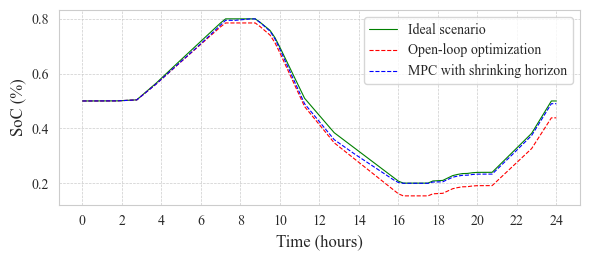

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

ideal_n = np.hstack([ideal, ideal[-1]])
one_time_n = np.hstack([one_time, one_time[-1]])
shrinking_n = np.hstack([shrinking, shrinking[-1]])
time_steps_n = np.hstack([time_steps, 24])

plt.figure(figsize=(6, 2.7))
plt.plot(time_steps_n, ideal_n, label='Ideal scenario', color='green', linewidth=0.8)
plt.plot(time_steps_n, one_time_n, '--', label='Open-loop optimization', color='red', linewidth=0.8)
plt.plot(time_steps_n, shrinking_n, '--', label='MPC with shrinking horizon', color='blue', linewidth=0.8)
plt.xticks(np.arange(0,25, 2))
# plt.fill_between(time_steps, 0, np.array(results['storage_energy'])/storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('SoC (%)', fontsize=12)
# plt.title('Battery Energy Storage')
plt.legend(loc='upper right')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('unmodeled.png', dpi=300, bbox_inches='tight', pad_inches=0.05)  # Save with 300 DPI


In [ ]:
ideal_n[-1], one_time_n[-1], shrinking_n[-1]

(0.5000000000000008, 0.438421052631579, 0.4901302556413048)

In [ ]:
ideal_n[-1] - one_time_n[-1]

0.06157894736842179

In [ ]:
ideal_n[-1] - shrinking_n[-1]

0.009869744358695975

In [ ]:
0.5- one_time_n[-1]/1

0.06157894736842101

In [ ]:
0.5-shrinking_n[-1]/1

0.009869744358695198

In [ ]:
0.12832982959937667 - 0.01660441286429748

0.11172541673507919

## visualize the results

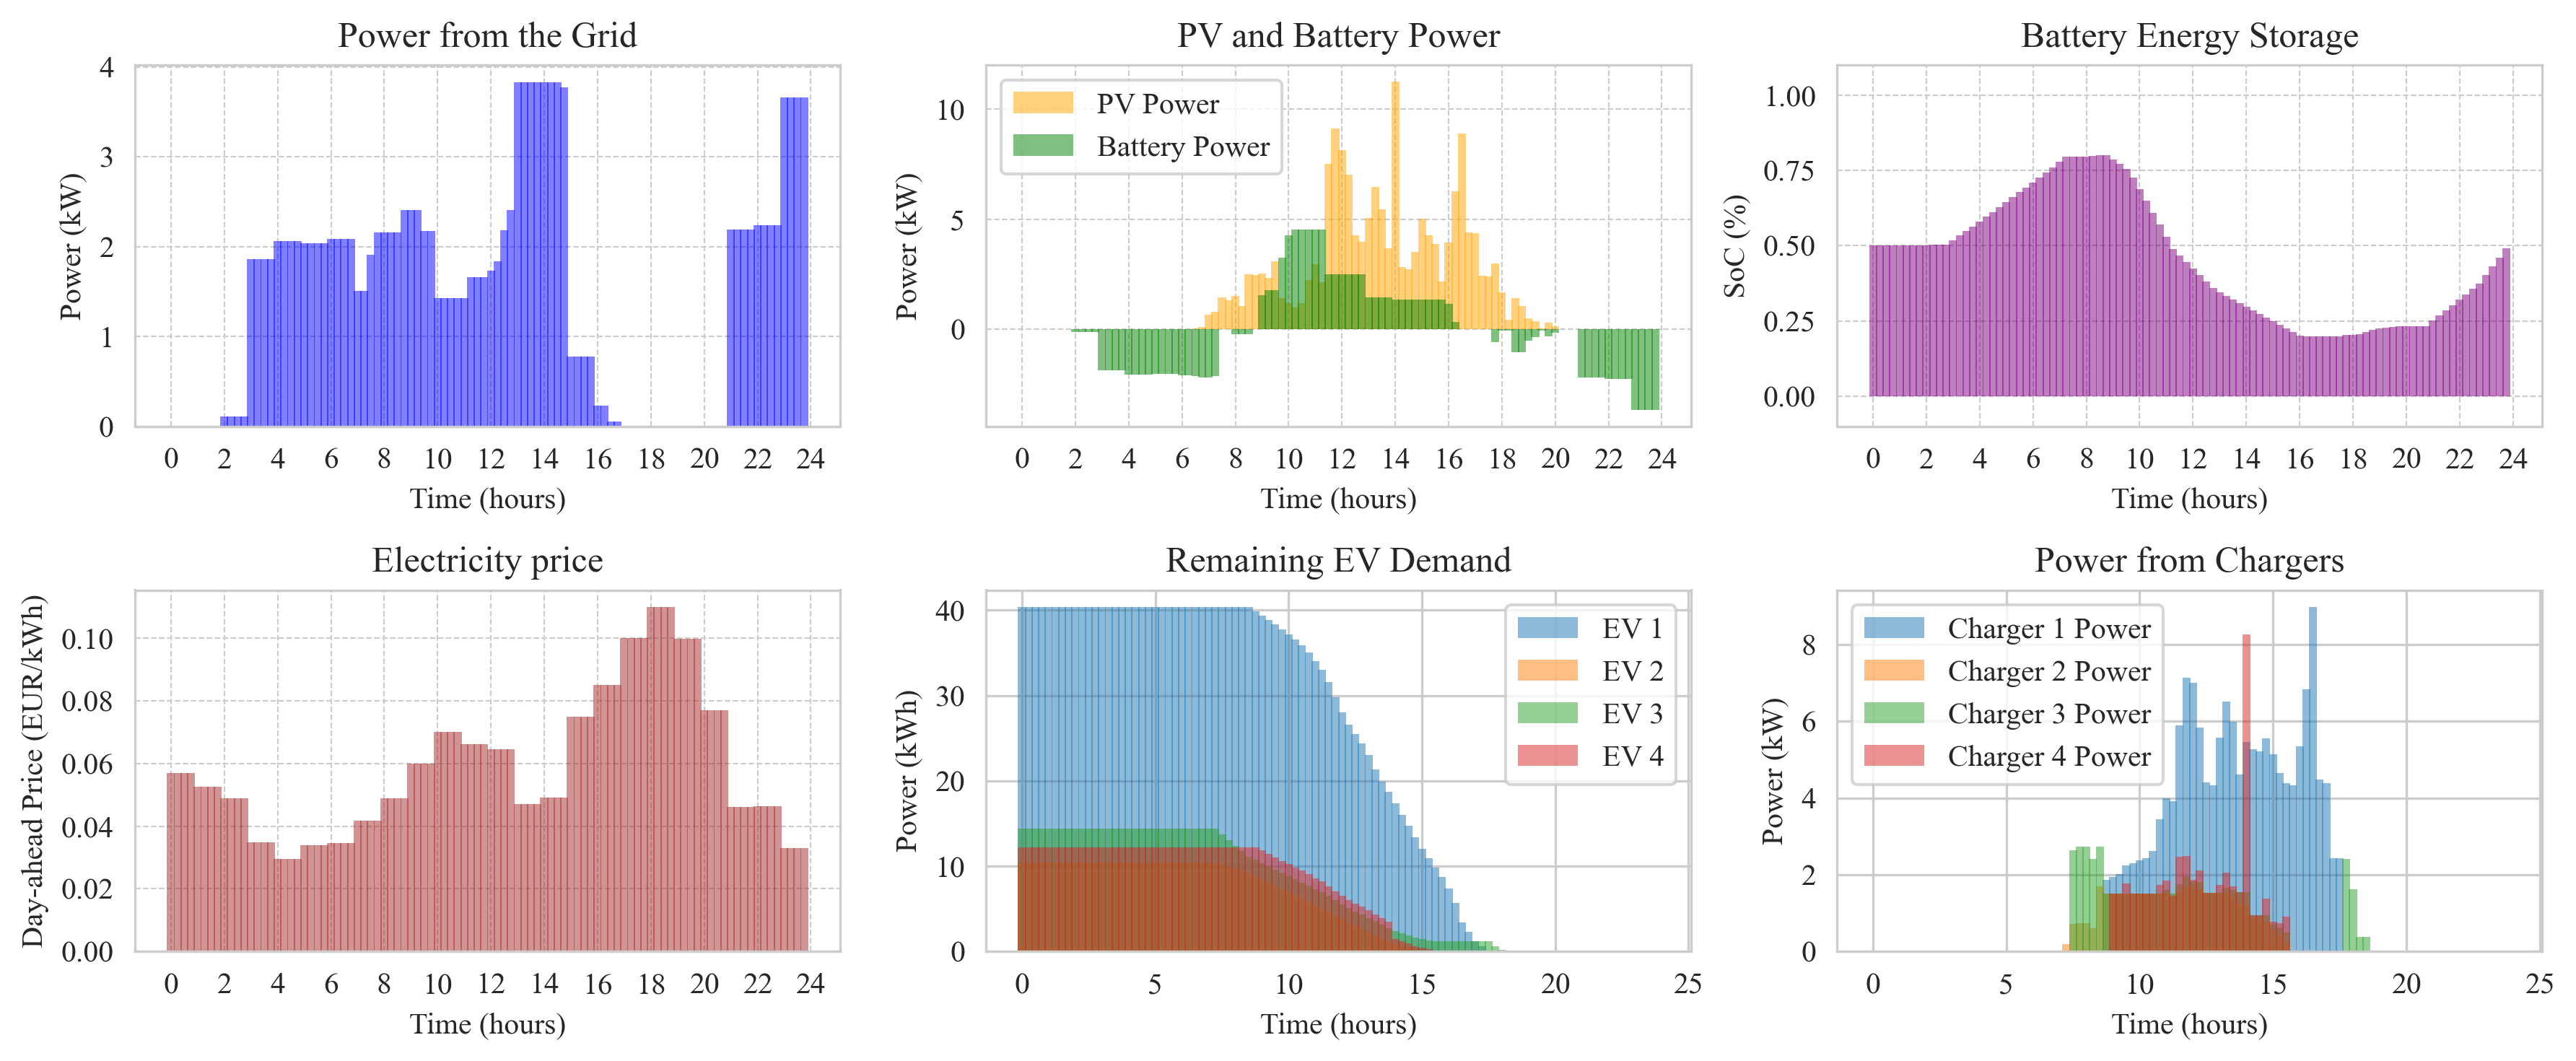

In [ ]:
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
    
plt.figure(figsize=(12, 5), dpi=300)
time_steps = np.arange(len(results['p_grid'])) / 4  # Scale the time steps to hours
hours = np.arange(0, 25, 2)  # Hours from 1 to 24

# Plot grid power
plt.subplot(2, 3, 1)
plt.bar(time_steps, results['p_grid'], label='Grid Power', color='blue', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.xticks(hours)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Plot PV power and battery power
plt.subplot(2, 3, 2)
plt.bar(time_steps, data_day[1:1+len(time_steps),4]/1000, label='PV Power', color='orange', alpha=0.5, width=0.3, edgecolor='none')
plt.bar(time_steps, results['p_storage'], label='Battery Power', color='green', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend(loc='upper left')
plt.xticks(hours)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


# Plot battery energy
plt.subplot(2, 3, 3)
plt.bar(time_steps, np.array(results['storage_energy'])/storage_capacity, label='Battery Energy', color='purple', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.xticks(hours)
plt.ylim([-0.1,1.1])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


# Plot electricity price
plt.subplot(2, 3, 4)
plt.bar(time_steps, expanded_prices[1:1+len(time_steps)]*4, label=f'p_price', color='brown', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Day-ahead Price (EUR/kWh)')
plt.title('Electricity price')
plt.xticks(hours)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


# Plot EV demand
plt.subplot(2, 3, 5)
for i in range(4):
    plt.bar(time_steps, results['remaining_demand'][:,i], label=f'EV {i+1}', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kWh)')
plt.title('Remaining EV Demand')
plt.legend()

# Plot charger power
plt.subplot(2, 3, 6)
for i in range(4):
    plt.bar(time_steps, results['p_chargers'][:,i], label=f'Charger {i+1} Power', alpha=0.5, width=0.3, edgecolor='none')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend(loc='upper left')


plt.tight_layout()
plt.show()

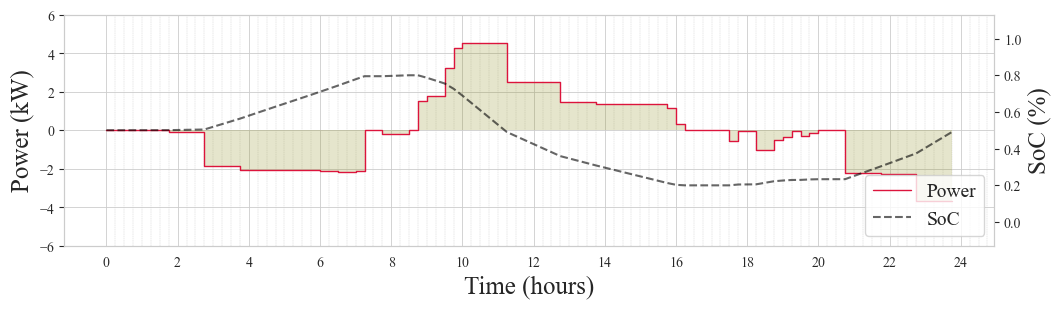

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(12, 3))

# Plot for ax1 (Battery Power)
plt.fill_between(time_steps, results['p_storage'], label='Power', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_storage'], color='crimson', linewidth=1, drawstyle='steps', label='Power')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-6, 6])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Storage SoC)
line2, = ax2.plot(time_steps, np.array(results['storage_energy']) / storage_capacity, '--', label='SoC', color='black', alpha=0.6, linewidth=1.5)

ax2.set_ylabel('SoC (%)', size=18)
ax2.set_ylim([-0.13, 1.13])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=14)

# Save the figure
plt.savefig('res_storage.png', dpi=300, bbox_inches='tight', pad_inches=0)


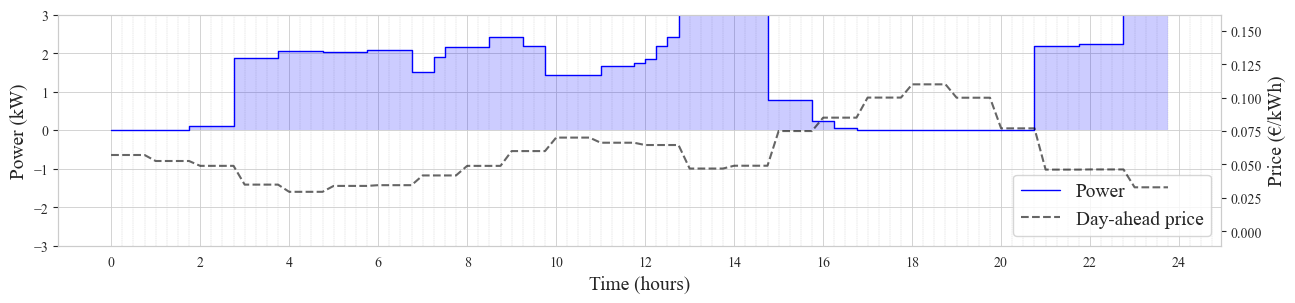

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(15, 3))

# Plot for ax1 (Grid Power)
plt.fill_between(time_steps, results['p_grid'], label='Power', color='blue', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_grid'], color='blue', linewidth=1, drawstyle='steps', label='Power')

ax1.set_xlabel('Time (hours)', size=14)
ax1.set_ylabel('Power (kW)', size=14)
ax1.set_ylim([-3,3])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Price)
line2, = ax2.plot(time_steps, expanded_prices[1:1+len(time_steps)]*4, '--', label='Day-ahead price', color='black', alpha=0.6, linewidth=1.5)
ax2.set_ylabel('Price (€/kWh)', size=14)
price_span = expanded_prices[1:1+len(time_steps)].max()*4-expanded_prices[1:1+len(time_steps)].min()*4
plt.ylim([expanded_prices[1:1+len(time_steps)].min()*4-price_span/2,expanded_prices[1:1+len(time_steps)].max()*4+price_span/2+0.012])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=14)

# Save the figure
plt.savefig('res_grid.png', dpi=300, bbox_inches='tight', pad_inches=0)


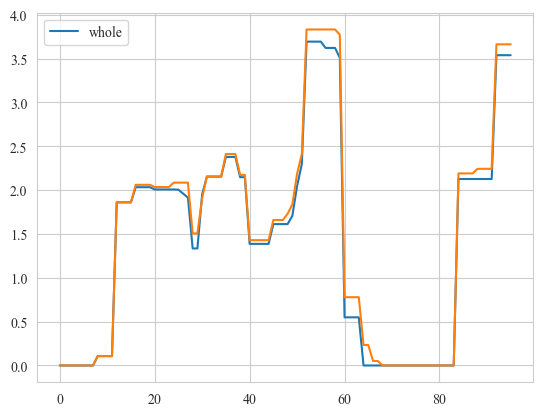

In [ ]:
plt.plot(p_grid.value[1:], label='whole')
plt.plot(results['p_grid'])
plt.legend()

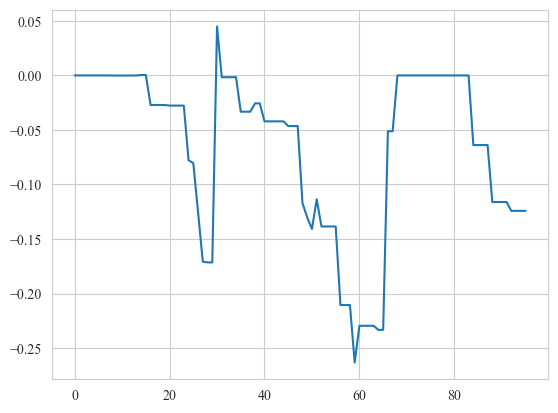

In [ ]:
plt.plot(p_grid.value[1:] - results['p_grid'])

In [ ]:
p_grid.value[1:]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.10692791, 0.10692791,
       0.10692791, 0.10692791, 1.8605018 , 1.8605018 , 1.86093491,
       1.86093491, 2.03319666, 2.03319666, 2.03319666, 2.03319666,
       2.00739848, 2.00739821, 2.00739821, 2.00739821, 2.00739821,
       2.00477599, 1.95986488, 1.91444266, 1.33454266, 1.33454266,
       1.95325518, 2.15389751, 2.15389751, 2.15389751, 2.15389751,
       2.37835353, 2.37835353, 2.37835353, 2.14748512, 2.14748512,
       1.38697647, 1.38697647, 1.38697647, 1.38697647, 1.38697647,
       1.61240646, 1.61240646, 1.61240646, 1.61240646, 1.70675256,
       2.0460167 , 2.29749881, 3.69352874, 3.69352874, 3.69352874,
       3.69352874, 3.62150225, 3.62150225, 3.62150225, 3.50963132,
       0.54908426, 0.54908426, 0.54908426, 0.54908426, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
results['p_grid']

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.10701804, 0.10701804,
       0.10701804, 0.10701804, 1.8605547 , 1.8605547 , 1.8605547 ,
       1.8605547 , 2.06031315, 2.06031315, 2.06031315, 2.06031315,
       2.03505867, 2.03505867, 2.03505867, 2.03505867, 2.08517493,
       2.08517493, 2.08517493, 2.08517493, 1.50599018, 1.50599018,
       1.90836718, 2.15551041, 2.15551041, 2.15551041, 2.15551041,
       2.41160804, 2.41160804, 2.41160804, 2.17309318, 2.17309318,
       1.42908003, 1.42908003, 1.42908003, 1.42908003, 1.42908003,
       1.65883553, 1.65883553, 1.65883553, 1.72937958, 1.83698197,
       2.18675795, 2.41104637, 3.83202007, 3.83202007, 3.83202007,
       3.83202007, 3.83202007, 3.83202007, 3.83202007, 3.77282405,
       0.77862882, 0.77862882, 0.77862882, 0.77862882, 0.23335026,
       0.23320011, 0.05117032, 0.05117032, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
np.sum(np.maximum(0, results['p_grid'])*expanded_prices[1:1+len(time_steps)] - np.maximum(0, -results['p_grid'])*expanded_prices[1:1+len(time_steps)]/2)

1.693677980014924

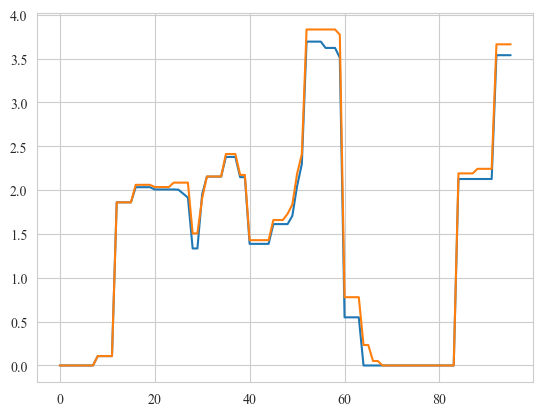

In [ ]:
plt.plot(p_grid_one_time)
plt.plot(results['p_grid'])

# plt.ylim([-0.2,0])

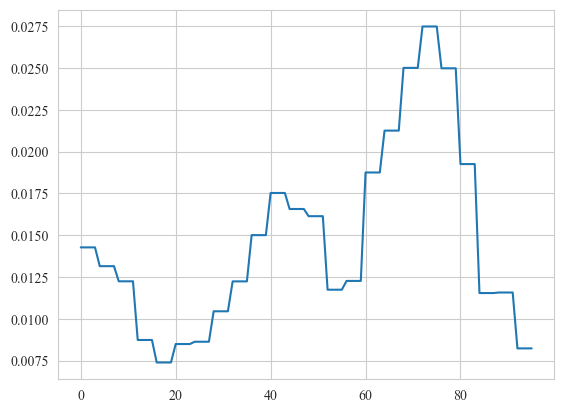

In [ ]:
plt.plot(expanded_prices[1:])

In [ ]:
np.sum(np.maximum(0, p_grid_one_time)*expanded_prices[1:1+len(time_steps)]), np.sum(np.maximum(0, results['p_grid'])*expanded_prices[1:1+len(time_steps)])

(1.6094188730680858, 1.693677980014924)

In [ ]:
results['storage_energy']

array([15.00144392, 15.00288785, 15.00433177, 15.00577569, 15.00721961,
       15.00866354, 15.01010746, 15.01155138, 15.03841209, 15.0652728 ,
       15.0921335 , 15.11899421, 15.56231987, 16.00564554, 16.4489712 ,
       16.89229687, 17.38306516, 17.87383346, 18.36460175, 18.85537005,
       19.34014041, 19.82491076, 20.30968112, 20.79445148, 21.29129432,
       21.78875994, 22.29689195, 22.81581173, 23.33473152, 23.83972257,
       23.83972257, 23.83972257, 23.89047717, 23.94123176, 23.99198636,
       23.99198636, 23.58914359, 23.1196158 , 22.65008802, 21.79393236,
       20.66737857, 19.47348955, 18.27960052, 17.08571149, 15.89182246,
       14.69793343, 14.04203318, 13.38613292, 12.73023267, 12.07433242,
       11.41843217, 10.76253191, 10.38167828, 10.00082464,  9.619971  ,
        9.23911737,  8.88043124,  8.52174512,  8.16305899,  7.80437286,
        7.44568674,  7.08700061,  6.72831449,  6.36962836,  6.06691973,
        5.98054588,  5.98054588,  5.98054588,  5.98054588,  5.98

In [ ]:
np.array(results['storage_energy'])

array([15.00144392, 15.00288785, 15.00433177, 15.00577569, 15.00721961,
       15.00866354, 15.01010746, 15.01155138, 15.03841209, 15.0652728 ,
       15.0921335 , 15.11899421, 15.56231987, 16.00564554, 16.4489712 ,
       16.89229687, 17.38306516, 17.87383346, 18.36460175, 18.85537005,
       19.34014041, 19.82491076, 20.30968112, 20.79445148, 21.29129432,
       21.78875994, 22.29689195, 22.81581173, 23.33473152, 23.83972257,
       23.83972257, 23.83972257, 23.89047717, 23.94123176, 23.99198636,
       23.99198636, 23.58914359, 23.1196158 , 22.65008802, 21.79393236,
       20.66737857, 19.47348955, 18.27960052, 17.08571149, 15.89182246,
       14.69793343, 14.04203318, 13.38613292, 12.73023267, 12.07433242,
       11.41843217, 10.76253191, 10.38167828, 10.00082464,  9.619971  ,
        9.23911737,  8.88043124,  8.52174512,  8.16305899,  7.80437286,
        7.44568674,  7.08700061,  6.72831449,  6.36962836,  6.06691973,
        5.98054588,  5.98054588,  5.98054588,  5.98054588,  5.98

In [ ]:
expanded_prices[-1]

0.0082325

In [ ]:
1.92

1.92

In [ ]:
(storage_capacity/2-np.array(results['storage_energy'])[-1]) * expanded_prices[-1] *2 


0.004875160225977506

In [ ]:
co2_df = pd.read_csv('data/CO2_2022.csv')
co2_df['validfrom (UTC)'] = pd.to_datetime(co2_df['validfrom (UTC)'])

# Extract year, month, day, and hour from the datetime
co2_df['Year'] =  co2_df['validfrom (UTC)'].dt.year
co2_df['Month'] = co2_df['validfrom (UTC)'].dt.month
co2_df['Day'] =   co2_df['validfrom (UTC)'].dt.day
co2_df['Hour'] =  co2_df['validfrom (UTC)'].dt.hour

# Select a specific day (e.g., January 1, 2022)
specific_day = co2_df[(co2_df['Year'] == 2022) & (co2_df['Month'] == 1) & (co2_df['Day'] == 1)]
co2_repeated = np.repeat(specific_day['emissionfactor (kg CO2/kWh)'], 4)


np.sum(np.abs(results['p_grid'])*co2_repeated)/4

7.627365516342022

In [ ]:
co2_repeated

1     0.244775
1     0.244775
1     0.244775
1     0.244775
2     0.254986
        ...   
23    0.213921
24    0.208648
24    0.208648
24    0.208648
24    0.208648
Name: emissionfactor (kg CO2/kWh), Length: 96, dtype: float64

In [ ]:
0.636515311428777/0.21212510344596902

3.0006599930352214

### p_chargers

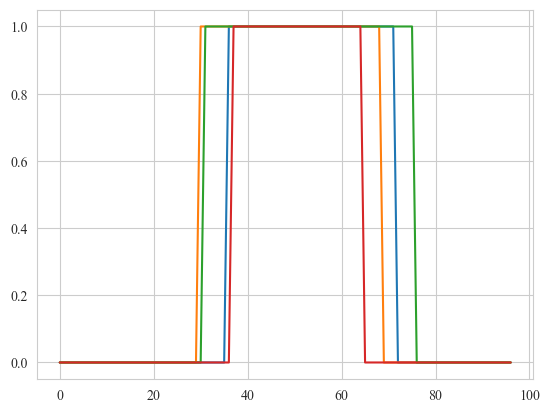

In [ ]:
plt.plot(charger_availability_data)

In [ ]:
ts = np.where(charger_availability_data[:,0]>0)
np.min(ts), np.max(ts)

(36, 71)

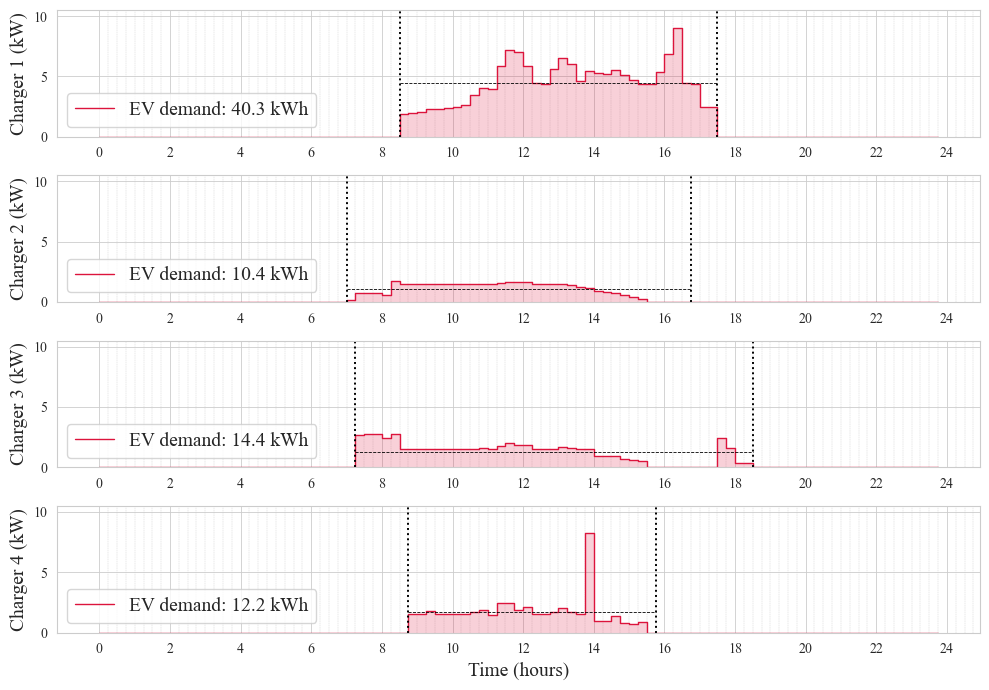

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, axes = plt.subplots(4, 1, figsize=(10, 7))

for i in range(len(axes)):
    # Plot for ax1 (Battery Power)
    axes[i].fill_between(time_steps, results['p_chargers'][:,i], color='crimson', alpha=0.2, edgecolor='None', step="pre")
    line1, = axes[i].plot(time_steps, results['p_chargers'][:,i], color='crimson', linewidth=1, drawstyle='steps', label=f'EV demand: {ev_demand_initial[0,i]:.1f} kWh')

    ts = np.where(charger_availability_data[1:,i]>0)
    axes[i].axvline(x = (np.min(ts)-1)/4, color = 'black', linestyle=':', linewidth=1.4)
    axes[i].axvline(x = (np.max(ts))/4, color = 'black', linestyle=':', linewidth=1.4)

    charging_time = np.arange(np.min(ts)-1, np.max(ts)+1)/4
    axes[i].plot(charging_time, np.repeat(ev_demand_initial[0,i]/(max(charging_time)-min(charging_time)), len(charging_time)) , color = 'black', linestyle='--', linewidth=0.6)

    axes[i].set_ylabel(f'Charger {i+1} (kW)', size=14)
    axes[i].set_ylim([0, 10.5])
    axes[i].grid(True, which='minor', linestyle='--', linewidth=0.3)
    axes[i].grid(True, which='major', linestyle='-', linewidth=0.6)

    # Set x-axis ticks
    minor_hours = np.arange(0, 25, 0.25)
    major_hours = np.arange(0, 25, 2)
    axes[i].set_xticks(minor_hours, minor=True)
    axes[i].set_xticks(major_hours, minor=False)

    # # Combine legends from both axes
    axes[i].legend(loc='lower left', fontsize=14)

axes[i].set_xlabel('Time (hours)', size=14)
plt.tight_layout()
# Save the figure
plt.savefig('res_chargers.png', dpi=300, bbox_inches='tight', pad_inches=0.1)


In [ ]:
ev_demand_initial[0,i]

12.203

In [ ]:
np.repeat(ev_demand_initial[0,i]/10, len(charging_time))

array([1.2203, 1.2203, 1.2203, 1.2203, 1.2203, 1.2203, 1.2203, 1.2203,
       1.2203, 1.2203, 1.2203, 1.2203, 1.2203, 1.2203, 1.2203, 1.2203,
       1.2203, 1.2203, 1.2203, 1.2203, 1.2203, 1.2203, 1.2203, 1.2203,
       1.2203, 1.2203, 1.2203, 1.2203, 1.2203])

In [ ]:
results['p_chargers'][:,0].shape

(96,)

In [ ]:
ev_demand_initial[0].shape

(4,)

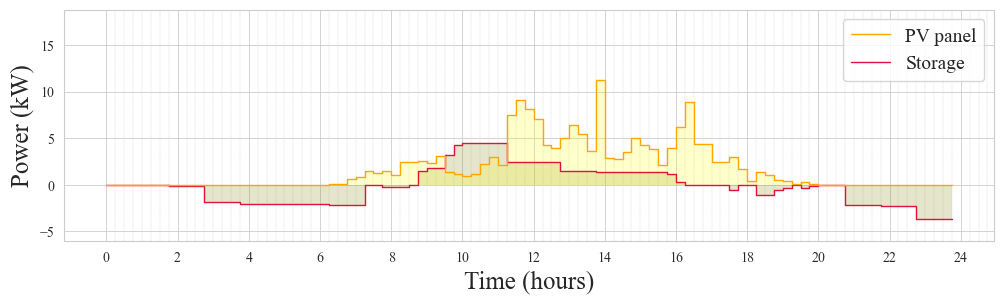

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(12, 3))

# Plot for ax1 (Battery Power)
ax1.fill_between(time_steps, results['p_storage'], label='Storage', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_storage'], color='crimson', linewidth=1, drawstyle='steps', label='Storage')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-6, 18.8])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)


# Plot for ax2 (Storage SoC)
ax1.fill_between(time_steps, data_day[1:, 4]/1000, label='PV panel', color='yellow', alpha=0.2, edgecolor='None', step="pre")
line2, = ax1.plot(time_steps, data_day[1:, 4]/1000, color='orange', linewidth=1, drawstyle='steps', label='PV panel')
# line2, = ax2.plot(time_steps, p_pv, '--', label='SoC', color='orange', alpha=0.6, linewidth=1.5, drawstyle='steps')


# Combine legends from both axes
lines = [line2, line1]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=14)

# Save the figure
plt.savefig('res_pv.png', dpi=300, bbox_inches='tight', pad_inches=0)


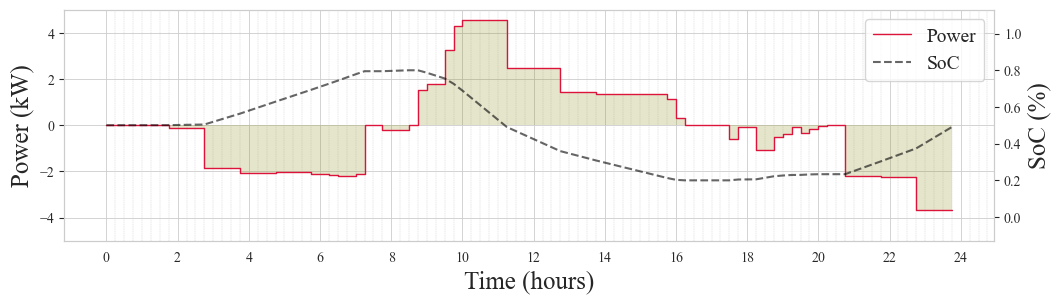

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create figure and first set of axes
fig, ax1 = plt.subplots(figsize=(12, 3))

# Plot for ax1 (Battery Power)
plt.fill_between(time_steps, results['p_storage'], label='Power', color='olive', alpha=0.2, edgecolor='None', step="pre")
line1, = ax1.plot(time_steps, results['p_storage'], color='crimson', linewidth=1, drawstyle='steps', label='Power')

ax1.set_xlabel('Time (hours)', size=18)
ax1.set_ylabel('Power (kW)', size=18)
ax1.set_ylim([-5, 5])
ax1.grid(True, which='minor', linestyle='--', linewidth=0.3)
ax1.grid(True, which='major', linestyle='-', linewidth=0.6)

# Set x-axis ticks
minor_hours = np.arange(0, 25, 0.25)
major_hours = np.arange(0, 25, 2)
plt.xticks(minor_hours, minor=True)
plt.xticks(major_hours, minor=False)

# Create second y-axis
ax2 = ax1.twinx()

# Plot for ax2 (Storage SoC)
line2, = ax2.plot(time_steps, np.array(results['storage_energy']) / storage_capacity, '--', label='SoC', color='black', alpha=0.6, linewidth=1.5)

ax2.set_ylabel('SoC (%)', size=18)
ax2.set_ylim([-0.13, 1.13])
ax2.grid(False)

# Combine legends from both axes
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=14)

# Save the figure
plt.savefig('res_storage.png', dpi=300, bbox_inches='tight', pad_inches=0)


# scalability

In [ ]:
np.hstack([np.array([20, 15, 25, 45])]*2).shape

(8,)

                                     CVXPY                                     
                                     v1.5.2                                    
(CVXPY) Feb 06 04:51:50 PM: Your problem has 2619 variables, 2933 constraints, and 0 parameters.
(CVXPY) Feb 06 04:51:50 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 06 04:51:50 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 06 04:51:50 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 06 04:51:50 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 06 04:51:50 PM: Compiling problem (target solver=SCIP).

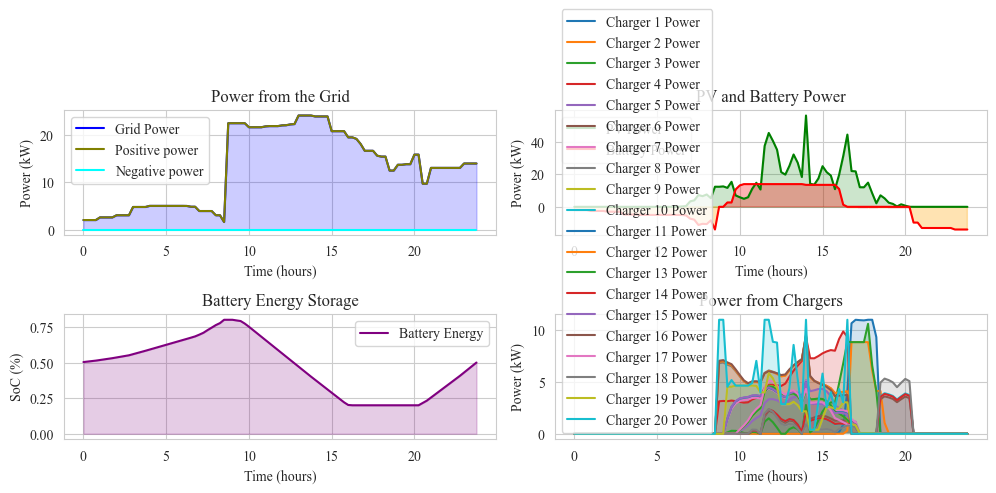

In [ ]:
SCALE_FACTOR = 5


import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4*SCALE_FACTOR

p_pv = data_day[:num_time_steps+1, 4]*SCALE_FACTOR / 1000  # PV power generation over time (size: num_time_steps)
charger_availability = np.hstack([data_day[:num_time_steps+1, :4]]*SCALE_FACTOR)  # Charger availability (size: num_chargers x num_time_steps)
ev_demand = np.hstack([np.array([20, 15, 25, 45])]*SCALE_FACTOR)  # Demand for each EV (size: num_chargers)
price = expanded_prices[:num_time_steps+1]

time_resolution = 0.25  # 15 minutes

# Storage constraints
storage_capacity = 30*SCALE_FACTOR  # Example capacity
capacity_high_limit = 0.8
capacity_low_limit = 0.2

charge_discharge_limit = 14  # Example charge/discharge limit
p_charger_limit = 11

# Decision Variables
p_chargers = cp.Variable((num_time_steps+1, num_chargers), nonneg=True)
p_grid = cp.Variable(num_time_steps+1)
p_grid_positive = cp.Variable(num_time_steps+1, nonneg=True)
p_grid_negative = cp.Variable(num_time_steps+1, nonneg=True)
p_storage = cp.Variable(num_time_steps+1)
storage_energy = cp.Variable(num_time_steps+1, nonneg=True)
slack = cp.Variable(num_time_steps+1)  # Slack variable for power balance constraints

# Binary variables for big-M method
binary_pos = cp.Variable(num_time_steps+1, boolean=True)

# Big-M constant
M = 1e5

# Constraints
constraints = []

# Charger availability constraints
constraints.append(p_chargers <= charger_availability * p_charger_limit)

# Power balance constraints
constraints.append(p_pv + p_grid + p_storage + slack == cp.sum(p_chargers, axis=1))

constraints.append(storage_energy <= storage_capacity * capacity_high_limit)
constraints.append(storage_energy >= storage_capacity * capacity_low_limit)
constraints.append(p_storage <= charge_discharge_limit)
constraints.append(p_storage >= -charge_discharge_limit)
constraints.append(storage_energy[0] == storage_capacity / 2)  # Initial storage level
constraints.append(storage_energy[-1] == storage_capacity / 2)

constraints.append(storage_energy[1:] == storage_energy[:-1] - p_storage[1:] * time_resolution)

# Initial conditions
# constraints.append(self.p_grid[0] == self.p_grid_initial)
constraints.append(p_grid_positive[0] == 0)
constraints.append(p_grid_negative[0] == 0)

# EV demand constraints
constraints.append(cp.sum(p_chargers * time_resolution, axis=0) >= ev_demand)

# Auxiliary variables constraints
constraints.append(p_grid == p_grid_positive - p_grid_negative)

# Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
constraints.append(binary_pos <= 1)
constraints.append(p_grid_positive <= binary_pos * M)
constraints.append(p_grid_negative <= (1-binary_pos) * M)

# Smoothing constraint to avoid abrupt changes
smoothing_penalty = cp.tv(p_grid_positive) + cp.tv(p_grid_negative) + cp.tv(p_storage) + 2*cp.tv(p_chargers) 

# Objective: Minimize total grid power usage, slack, and smoothing
objective = cp.Minimize(
    cp.sum(p_grid ** 2) +
    cp.sum(cp.multiply(price, p_grid_positive)) * 1000 -
    cp.sum(cp.multiply(price/2, p_grid_negative)) * 1000 +
    cp.sum(slack ** 2) * 1e3 +
    smoothing_penalty
)

# Problem definition and solving
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCIP, verbose=True)

# Output the results
print("Problem status:", problem.status)
if problem.status not in ["infeasible", "unbounded"]:
    print("Optimal objective value:", objective.value)
else:
    print("The problem is infeasible or unbounded.")

plt.figure(figsize=(10, 6))
time_steps = np.arange(len(p_grid.value[1:])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 2, 1)
plt.plot(time_steps, p_grid.value[1:], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, p_grid.value[1:], color='blue', alpha=0.2)
plt.plot(time_steps, p_grid_positive.value[1:], label='Positive power', color='olive')
plt.plot(time_steps, -p_grid_negative.value[1:], label='Negative power', color='cyan')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 2, 2)
plt.plot(time_steps, p_pv[1:], label='PV Power', color='green')
plt.fill_between(time_steps, 0, p_pv[1:], color='green', alpha=0.2)
plt.plot(time_steps, p_storage.value[1:], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 2, 3)
plt.plot(time_steps, np.array(storage_energy.value[1:]) / storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(storage_energy.value[1:]) / storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot charger power
plt.subplot(2, 2, 4)
for i in range(4*SCALE_FACTOR):
    plt.plot(time_steps, p_chargers.value[1:, i], label=f'Charger {i + 1} Power')
    plt.fill_between(time_steps, 0, p_chargers.value[1:, i], alpha=0.2)

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()
